# **DEEP LEARNING (Assignment-2)**

---------------------------
---------------------------

### **Part 1: Geometry of Convolutions**

In this part, we emphasize understanding the geometry of CNN layers by manually & experimentally verifying how feature-map sizes change:

-> *First, we manually compute the spatial size and channels **(H,W,C)** after every layer for a CNN with **3× Conv (3×3), 2× MaxPool (2×2, stride=2), and 1× Fully Connected layer.***

-> *Then, we implement the exact same architecture in **PyTorch** and verify the manual dimension map by printing tensor shapes using **print(x.shape)**.*

-> *Finally, we show how removing pooling causes a **parameter explosion** in the final FC layer because the flattened feature map becomes much larger.*

---------------------------
---------------------------

In [1]:
#Importing required libraries
import torch.nn as nn
import pandas as pd
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

#Load tiny-imagenet data
TRAIN_DIR = r"/home/ss_students/17MHT/DL/A2/tiny-imagenet/train"

#Standardize inputs
tfm = transforms.Compose([
    transforms.Resize((64, 64)),  #resize to 64x64 
    transforms.ToTensor(),  #converts pixel range from [0,255] → [0,1]
])

train_ds = datasets.ImageFolder(TRAIN_DIR, transform=tfm)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=0)

#### **A: Manual dimension map (H, W, C)**

In [2]:
# Output size after applying a Convolution layer
def conv_out(h, w, k=3, s=1, p=1):
    ho = (h + 2*p - k)//s + 1
    wo = (w + 2*p - k)//s + 1
    return ho, wo

# Output size after applying a Max-Pooling layer
def pool_out(h, w, k=2, s=2):
    ho = (h - k)//s + 1
    wo = (w - k)//s + 1
    return ho, wo

layers = []
manual_map = {}

H, W, C = 64, 64, 3
manual_map["Input"] = (H, W, C)

# Conv1: 3 -> 16 (k=3, s=1, p=1 keeps H,W)
H, W = conv_out(H, W, k=3, s=1, p=1); C = 16
manual_map["Conv1"] = (H, W, C)

# Conv2: 16 -> 32
H, W = conv_out(H, W, k=3, s=1, p=1); C = 32
manual_map["Conv2"] = (H, W, C)

# Pool1: 2x2, stride=2 halves H,W
H, W = pool_out(H, W, k=2, s=2)
manual_map["Pool1"] = (H, W, C)

# Conv3: 32 -> 64
H, W = conv_out(H, W, k=3, s=1, p=1); C = 64
manual_map["Conv3"] = (H, W, C)

# Pool2: 2x2, stride=2 halves H,W again
H, W = pool_out(H, W, k=2, s=2)
manual_map["Pool2"] = (H, W, C)

# Flatten features for FC (with pooling)
flat_with_pool = H * W * C
manual_map["Flatten"] = flat_with_pool

# FC output classes
manual_map["FC out"] = len(train_ds.classes)

#### **B: PyTorch model (records shapes)**

In [3]:
class ModelCNN(nn.Module):
    def __init__(self, num_classes=len(train_ds.classes), use_pool=True, in_features=None):
        super().__init__()
        self.use_pool = use_pool

        # 3 conv layers (3x3)
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)

        # activation + pooling
        self.relu = nn.ReLU(inplace=True)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # FC input size depends on pooling choice
        self.fc = nn.Linear(in_features, num_classes)

    def forward(self, x, debug=False):
        shapes = {}

        # record input
        if debug: shapes["Input"] = x.shape

        # conv1
        x = self.relu(self.conv1(x))
        if debug: shapes["Conv1"] = x.shape

        # conv2
        x = self.relu(self.conv2(x))
        if debug: shapes["Conv2"] = x.shape

        # pool1 (optional)
        if self.use_pool:
            x = self.pool(x)
            if debug: shapes["Pool1"] = x.shape

        # conv3
        x = self.relu(self.conv3(x))
        if debug: shapes["Conv3"] = x.shape

        # pool2 (optional)
        if self.use_pool:
            x = self.pool(x)
            if debug: shapes["Pool2"] = x.shape

        # flatten
        x = x.flatten(1)
        if debug: shapes["Flatten"] = x.shape

        # fc
        x = self.fc(x)
        if debug: shapes["FC out"] = x.shape

        return (x, shapes) if debug else x

#### **Build Layer-wise table (Manual vs PyTorch) to verify our manual calculations.**

In [4]:
model_pool = ModelCNN(num_classes=len(train_ds.classes), use_pool=True,  in_features=flat_with_pool)

xb, yb = next(iter(train_loader)) # On one batch
_, shapes_pool = model_pool(xb, debug=True)

layer_order = ["Input","Conv1","Conv2","Pool1","Conv3","Pool2","Flatten","FC out"]

rows = []
for layer in layer_order:
    manual_val = manual_map.get(layer, "-")
    torch_val  = shapes_pool.get(layer, "-")  

    rows.append({
        "Layer": layer,
        "Manual dimension map (H, W, C)": manual_val,
        "PyTorch (N, C, H, W)": str(torch_val) if torch_val != "-" else "-"
    })

df_shapes = pd.DataFrame(rows)
display(df_shapes)

,Layer,"Manual dimension map (H, W, C)","PyTorch (N, C, H, W)"
0,Input,"(64, 64, 3)","torch.Size([32, 3, 64, 64])"
1,Conv1,"(64, 64, 16)","torch.Size([32, 16, 64, 64])"
2,Conv2,"(64, 64, 32)","torch.Size([32, 32, 64, 64])"
3,Pool1,"(32, 32, 32)","torch.Size([32, 32, 32, 32])"
4,Conv3,"(32, 32, 64)","torch.Size([32, 64, 32, 32])"
5,Pool2,"(16, 16, 64)","torch.Size([32, 64, 16, 16])"
6,Flatten,16384,"torch.Size([32, 16384])"
7,FC out,10,"torch.Size([32, 10])"


#### **Total Parameter comparison (with & without pooling)**

In [5]:
# Manual totals (formula-based)

Hn, Wn, Cn = 64, 64, 3
Hn, Wn = conv_out(Hn, Wn, k=3, s=1, p=1); Cn = 16
Hn, Wn = conv_out(Hn, Wn, k=3, s=1, p=1); Cn = 32
Hn, Wn = conv_out(Hn, Wn, k=3, s=1, p=1); Cn = 64
flat_no_pool = Hn * Wn * Cn

def conv_params(in_ch, out_ch, k=3):
    return out_ch*(in_ch*k*k) + out_ch

conv_total = (
    conv_params(3,16,3) +
    conv_params(16,32,3) +
    conv_params(32,64,3)
)

def fc_params(in_features, out_features):
    return in_features*out_features + out_features 

manual_fc_with = fc_params(flat_with_pool, len(train_ds.classes))
manual_fc_no   = fc_params(flat_no_pool, len(train_ds.classes))

manual_total_with = conv_total + manual_fc_with
manual_total_no   = conv_total + manual_fc_no

# PyTorch totals (counted from model)

model_nop  = ModelCNN(num_classes=len(train_ds.classes), use_pool=False, in_features=flat_no_pool)

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

torch_total_with = count_params(model_pool)
torch_total_no   = count_params(model_nop)

torch_fc_with = model_pool.fc.weight.numel() + model_pool.fc.bias.numel()
torch_fc_no   = model_nop.fc.weight.numel() + model_nop.fc.bias.numel()

# Parameter Comparison Table

df_params = pd.DataFrame([
    {"Parameter": "Total (with pooling)",    "Manual": manual_total_with, "PyTorch": torch_total_with},
    {"Parameter": "Total (without pooling)", "Manual": manual_total_no,   "PyTorch": torch_total_no},
    {"Parameter": "Total (without-with pooling)", "Manual": manual_total_no-manual_total_with,   "PyTorch": torch_total_no-torch_total_with},
    {"Parameter": "FC only (with pooling)",  "Manual": manual_fc_with,    "PyTorch": torch_fc_with},
    {"Parameter": "FC only (without pooling)","Manual": manual_fc_no,     "PyTorch": torch_fc_no},
    {"Parameter": "FC only (without-with pooling)","Manual": manual_fc_no-manual_fc_with,     "PyTorch": torch_fc_no-torch_fc_with},
])

display(df_params)

,Parameter,Manual,PyTorch
0,Total (with pooling),187434,187434
1,Total (without pooling),2645034,2645034
2,Total (without-with pooling),2457600,2457600
3,FC only (with pooling),163850,163850
4,FC only (without pooling),2621450,2621450
5,FC only (without-with pooling),2457600,2457600


# Part 2: The "Why CNN?" Experiment (Spatial Invariance)

## Assignment Overview

**Goal**: Demonstrate why Convolutional Neural Networks (CNNs) outperform Fully Connected Neural Networks (FCNNs) for vision tasks.

**Key Question**: What property makes CNNs robust to spatial transformations?

---

## Question 2.1: The Robustness Duel

### The Task
Train two models on MNIST:
1. **Model A**: Best FCNN from previous assignment
2. **Model B**: Simple 2-layer CNN

### The Test
Create a "Shifted MNIST" test set by translating every image **4 pixels to the right**.

### The Deliverable
- Report accuracy drop for both models
- Explain why CNN maintains higher accuracy
- Analyze the role of weight sharing in spatial invariance

## 1. Setup and Imports

In [1]:
# Install required packages
import sys
import subprocess

# Install PyTorch if not already installed
try:
    import torch
except ImportError:
    print("Installing PyTorch...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch", "torchvision"])

print("All packages ready!")

All packages ready!


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import pandas as pd

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set style for plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

Using device: cuda


## 2. Data Loading and Preprocessing

We'll load the MNIST dataset and create both:
- Original test set
- Shifted test set (4 pixels to the right)

In [3]:
def load_mnist_data():
    """
    Load MNIST dataset with normalization.
    Returns train and test loaders.
    """
    # Define transforms
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
    ])

    # Load datasets
    train_dataset = datasets.MNIST(
        root='./data',
        train=True,
        download=True,
        transform=transform
    )

    test_dataset = datasets.MNIST(
        root='./data',
        train=False,
        download=True,
        transform=transform
    )

    # Create data loaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=128,
        shuffle=True,
        num_workers=2
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=128,
        shuffle=False,
        num_workers=2
    )

    return train_loader, test_loader, train_dataset, test_dataset

# Load data
train_loader, test_loader, train_dataset, test_dataset = load_mnist_data()

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Image shape: {train_dataset[0][0].shape}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 513kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.69MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.64MB/s]

Training samples: 60000
Test samples: 10000
Image shape: torch.Size([1, 28, 28])


## 3. Creating Shifted MNIST Test Set

We'll create a version of the test set where all images are shifted 4 pixels to the right.

In [4]:
def shift_images(images, shift_pixels=4, direction='right'):
    """
    Shift images by a specified number of pixels.

    Args:
        images: Tensor of shape (N, C, H, W)
        shift_pixels: Number of pixels to shift
        direction: 'right', 'left', 'up', or 'down'

    Returns:
        Shifted images tensor
    """
    shifted = torch.zeros_like(images)

    if direction == 'right':
        shifted[:, :, :, shift_pixels:] = images[:, :, :, :-shift_pixels]
    elif direction == 'left':
        shifted[:, :, :, :-shift_pixels] = images[:, :, :, shift_pixels:]
    elif direction == 'down':
        shifted[:, :, shift_pixels:, :] = images[:, :, :-shift_pixels, :]
    elif direction == 'up':
        shifted[:, :, :-shift_pixels, :] = images[:, :, shift_pixels:, :]

    return shifted

def create_shifted_test_loader(test_dataset, shift_pixels=4):
    """
    Create a data loader with shifted test images.
    """
    # Extract all test images and labels
    test_images = test_dataset.data.float().unsqueeze(1) / 255.0  # Normalize to [0, 1]
    test_labels = test_dataset.targets

    # Apply MNIST normalization
    test_images = (test_images - 0.1307) / 0.3081

    # Shift images
    shifted_images = shift_images(test_images, shift_pixels=shift_pixels, direction='right')

    # Create dataset and loader
    shifted_dataset = TensorDataset(shifted_images, test_labels)
    shifted_loader = DataLoader(shifted_dataset, batch_size=128, shuffle=False)

    return shifted_loader, shifted_images, test_labels

# Create shifted test set
shifted_test_loader, shifted_images, test_labels = create_shifted_test_loader(test_dataset)

print(f"Shifted test set created: {len(shifted_images)} images")

Shifted test set created: 10000 images


### Visualize Original vs Shifted Images

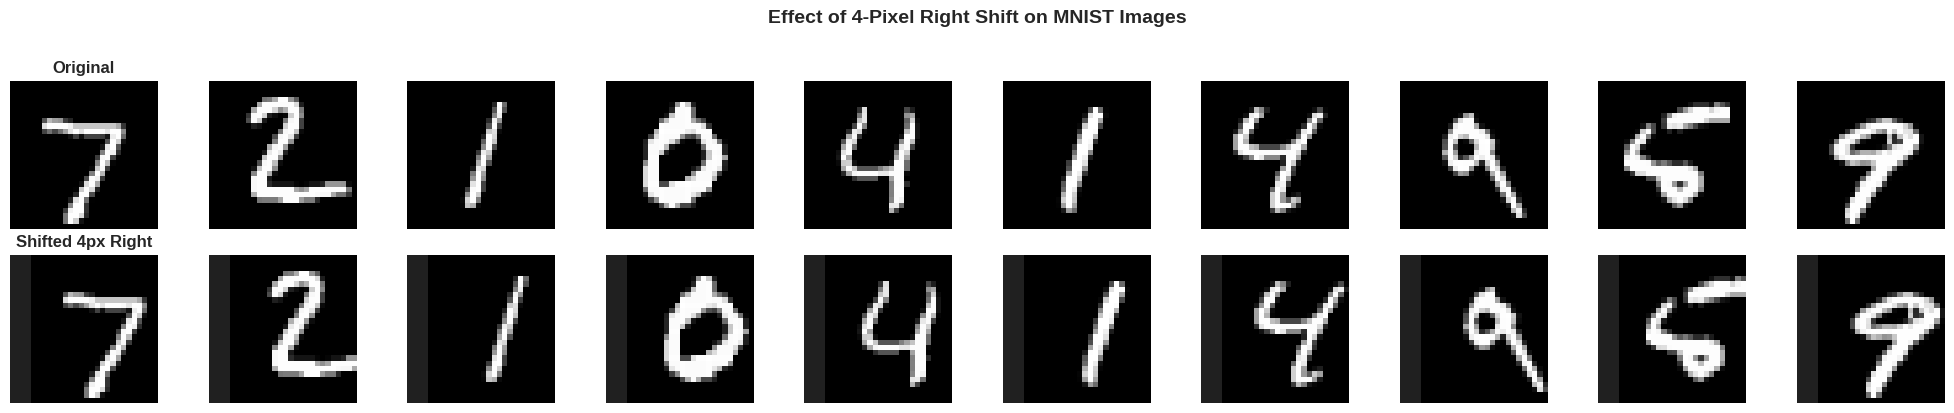

In [5]:
def visualize_shift_effect(test_dataset, shifted_images, num_samples=10):
    """
    Visualize original and shifted images side by side.
    """
    fig, axes = plt.subplots(2, num_samples, figsize=(20, 4))

    for i in range(num_samples):
        # Original image
        original = test_dataset[i][0].squeeze()
        axes[0, i].imshow(original, cmap='gray')
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_title('Original', fontsize=12, fontweight='bold')

        # Shifted image
        shifted = shifted_images[i].squeeze()
        axes[1, i].imshow(shifted, cmap='gray')
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_title('Shifted 4px Right', fontsize=12, fontweight='bold')

    plt.suptitle('Effect of 4-Pixel Right Shift on MNIST Images',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('shift_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()

# Visualize the shift effect
visualize_shift_effect(test_dataset, shifted_images)

## 4. Model A: Fully Connected Neural Network (FCNN)

**This is the best-performing FCNN from Assignment 1**, which achieved ~98.3% test accuracy on standard MNIST.

From the previous assignment results:
- Architecture: 784 → 512 → 256 → 10
- Dropout: 0.2
- Optimizer: Adam (lr=0.001)
- Final Test Accuracy: 98.30%

We reproduce this exact architecture here to ensure a fair comparison with the CNN.

In [6]:
class FCNN(nn.Module):
    """
    Fully Connected Neural Network (FCNN) for MNIST.

    This is the EXACT architecture from Assignment 1 that achieved 98.3% accuracy.

    Architecture (matches previous assignment):
    - Input: 784 (28x28 flattened)
    - Hidden Layer 1: 512 neurons with ReLU + Dropout(0.2)
    - Hidden Layer 2: 256 neurons with ReLU + Dropout(0.2)
    - Output: 10 classes

    Key Properties:
    - Dense connections: Every pixel connects to every hidden neuron
    - Position-specific weights: Different weights for pixel at (i,j) vs (i+4,j)
    - No spatial structure awareness
    """
    def __init__(self, input_size=784, hidden1=512, hidden2=256,
                 num_classes=10, dropout_rate=0.2):
        super(FCNN, self).__init__()

        self.fc1 = nn.Linear(input_size, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, num_classes)
        self.dropout = nn.Dropout(dropout_rate)

        # He initialization (same as Assignment 1)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        # Flatten the input
        x = x.view(x.size(0), -1)

        # Layer 1
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)

        # Layer 2
        x = self.fc2(x)
        x = F.relu(x)
        x = self.dropout(x)

        # Output
        x = self.fc3(x)
        return x

# Initialize Model A (exact architecture from Assignment 1)
model_fcnn = FCNN().to(device)

print("="*70)
print("Model A: Best FCNN from Assignment 1")
print("="*70)

# Count parameters
fcnn_params = sum(p.numel() for p in model_fcnn.parameters())
print(f"Model A (FCNN) initialized")
print(f"Total parameters: {fcnn_params:,}")
print(f"\nArchitecture:")
print(model_fcnn)

Model A: Best FCNN from Assignment 1
Model A (FCNN) initialized
Total parameters: 535,818

Architecture:
FCNN(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=10, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)


## 5. Model B: Convolutional Neural Network (CNN)

A simple 2-layer CNN that leverages spatial structure and weight sharing.

In [7]:
class SimpleCNN(nn.Module):
    """
    Simple 2-Layer Convolutional Neural Network for MNIST.

    Architecture:
    - Conv Layer 1: 32 filters, 3x3 kernel, ReLU, MaxPool
    - Conv Layer 2: 64 filters, 3x3 kernel, ReLU, MaxPool
    - Fully Connected Layer: 128 neurons
    - Output: 10 classes

    Key Properties:
    - Weight sharing: Same filter weights applied across entire image
    - Local connectivity: Each neuron only looks at small region
    - Translation invariance: Features detected regardless of position
    """
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()

        # Convolutional Layer 1
        self.conv1 = nn.Conv2d(
            in_channels=1,      # Grayscale input
            out_channels=32,    # 32 feature maps
            kernel_size=3,      # 3x3 filters
            padding=1           # Keep spatial dimensions
        )
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)  # 28x28 -> 14x14

        # Convolutional Layer 2
        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,    # 64 feature maps
            kernel_size=3,
            padding=1
        )
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)  # 14x14 -> 7x7

        # Fully connected layers
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        # Conv Layer 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool1(x)

        # Conv Layer 2
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.pool2(x)

        # Flatten
        x = x.view(x.size(0), -1)

        # Fully connected layers
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)

        return x

# Initialize Model B
model_cnn = SimpleCNN().to(device)

# Count parameters
cnn_params = sum(p.numel() for p in model_cnn.parameters())
print(f"Model B (CNN) initialized")
print(f"Total parameters: {cnn_params:,}")
print(f"\nParameter comparison:")
print(f"  FCNN: {fcnn_params:,}")
print(f"  CNN:  {cnn_params:,}")
print(f"  Reduction: {((fcnn_params - cnn_params) / fcnn_params * 100):.1f}%")
print(f"\nArchitecture:")
print(model_cnn)

Model B (CNN) initialized
Total parameters: 421,834

Parameter comparison:
  FCNN: 535,818
  CNN:  421,834
  Reduction: 21.3%

Architecture:
SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


## 6. Training Functions

In [8]:
def train_model(model, train_loader, criterion, optimizer, num_epochs=10, model_name="Model"):
    """
    Train a model and track metrics.
    """
    model.train()
    history = {
        'train_loss': [],
        'train_acc': []
    }

    print(f"\nTraining {model_name}...")
    print("=" * 70)

    for epoch in range(num_epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        # Progress bar
        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')

        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass
            loss.backward()
            optimizer.step()

            # Statistics
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # Update progress bar
            pbar.set_postfix({
                'loss': f'{running_loss / (pbar.n + 1):.4f}',
                'acc': f'{100 * correct / total:.2f}%'
            })

        # Epoch statistics
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc)

        print(f"Epoch {epoch+1}: Loss = {epoch_loss:.4f}, Accuracy = {epoch_acc:.2f}%")

    print("=" * 70)
    print(f"{model_name} training completed!\n")

    return history

def evaluate_model(model, test_loader, model_name="Model"):
    """
    Evaluate a model on a test set.
    """
    model.eval()
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f'Evaluating {model_name}'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total
    return accuracy, np.array(all_predictions), np.array(all_labels)

## 7. Training Model A (FCNN)

In [9]:
# Define training parameters for FCNN
criterion_fcnn = nn.CrossEntropyLoss()
optimizer_fcnn = optim.Adam(model_fcnn.parameters(), lr=0.001)
num_epochs = 10

# Train FCNN
history_fcnn = train_model(
    model_fcnn,
    train_loader,
    criterion_fcnn,
    optimizer_fcnn,
    num_epochs=num_epochs,
    model_name="Model A (FCNN)"
)


Training Model A (FCNN)...


Epoch 1/10: 100%|██████████| 469/469 [00:13<00:00, 34.81it/s, loss=0.2745, acc=91.49%]


Epoch 1: Loss = 0.2727, Accuracy = 91.49%


Epoch 2/10: 100%|██████████| 469/469 [00:12<00:00, 37.12it/s, loss=0.1235, acc=96.22%]


Epoch 2: Loss = 0.1229, Accuracy = 96.22%


...

Epoch 8: Loss = 0.0404, Accuracy = 98.63%


Epoch 9/10: 100%|██████████| 469/469 [00:12<00:00, 36.37it/s, loss=0.0422, acc=98.60%]


Epoch 9: Loss = 0.0419, Accuracy = 98.60%


Epoch 10/10: 100%|██████████| 469/469 [00:12<00:00, 36.20it/s, loss=0.0390, acc=98.74%]


Epoch 10: Loss = 0.0387, Accuracy = 98.74%
Model A (FCNN) training completed!



## 8. Training Model B (CNN)

In [10]:
# Define training parameters for CNN
criterion_cnn = nn.CrossEntropyLoss()
optimizer_cnn = optim.Adam(model_cnn.parameters(), lr=0.001)

# Train CNN
history_cnn = train_model(
    model_cnn,
    train_loader,
    criterion_cnn,
    optimizer_cnn,
    num_epochs=num_epochs,
    model_name="Model B (CNN)"
)


Training Model B (CNN)...


Epoch 1/10: 100%|██████████| 469/469 [00:14<00:00, 32.80it/s, loss=0.2151, acc=93.27%]


Epoch 1: Loss = 0.2151, Accuracy = 93.27%


Epoch 2/10: 100%|██████████| 469/469 [00:13<00:00, 35.64it/s, loss=0.0867, acc=97.48%]


Epoch 2: Loss = 0.0865, Accuracy = 97.48%


...

Epoch 8: Loss = 0.0367, Accuracy = 98.84%


Epoch 9/10: 100%|██████████| 469/469 [00:13<00:00, 35.85it/s, loss=0.0340, acc=98.91%]


Epoch 9: Loss = 0.0340, Accuracy = 98.91%


Epoch 10/10: 100%|██████████| 469/469 [00:13<00:00, 35.69it/s, loss=0.0336, acc=98.91%]

Epoch 10: Loss = 0.0336, Accuracy = 98.91%
Model B (CNN) training completed!



## 9. Evaluation on Original Test Set

In [11]:
# Evaluate FCNN on original test set
fcnn_original_acc, fcnn_orig_preds, fcnn_orig_labels = evaluate_model(
    model_fcnn, test_loader, "FCNN on Original"
)

# Evaluate CNN on original test set
cnn_original_acc, cnn_orig_preds, cnn_orig_labels = evaluate_model(
    model_cnn, test_loader, "CNN on Original"
)

print("\n" + "="*70)
print("RESULTS ON ORIGINAL TEST SET")
print("="*70)
print(f"Model A (FCNN): {fcnn_original_acc:.2f}%")
print(f"Model B (CNN):  {cnn_original_acc:.2f}%")
print("="*70)

Evaluating CNN on Original: 100%|██████████| 79/79 [00:02<00:00, 31.70it/s]


RESULTS ON ORIGINAL TEST SET
Model A (FCNN): 98.22%
Model B (CNN):  99.25%


## 10. Evaluation on Shifted Test Set

In [12]:
# Evaluate FCNN on shifted test set
fcnn_shifted_acc, fcnn_shift_preds, fcnn_shift_labels = evaluate_model(
    model_fcnn, shifted_test_loader, "FCNN on Shifted"
)

# Evaluate CNN on shifted test set
cnn_shifted_acc, cnn_shift_preds, cnn_shift_labels = evaluate_model(
    model_cnn, shifted_test_loader, "CNN on Shifted"
)

print("\n" + "="*70)
print("RESULTS ON SHIFTED TEST SET (4 pixels right)")
print("="*70)
print(f"Model A (FCNN): {fcnn_shifted_acc:.2f}%")
print(f"Model B (CNN):  {cnn_shifted_acc:.2f}%")
print("="*70)

Evaluating CNN on Shifted: 100%|██████████| 79/79 [00:00<00:00, 374.98it/s]


RESULTS ON SHIFTED TEST SET (4 pixels right)
Model A (FCNN): 42.02%
Model B (CNN):  83.22%


## 11. Accuracy Drop Analysis

In [13]:
# Calculate accuracy drops
fcnn_drop = fcnn_original_acc - fcnn_shifted_acc
cnn_drop = cnn_original_acc - cnn_shifted_acc
fcnn_drop_pct = (fcnn_drop / fcnn_original_acc) * 100
cnn_drop_pct = (cnn_drop / cnn_original_acc) * 100

# Create summary dataframe
results_df = pd.DataFrame({
    'Model': ['FCNN', 'CNN'],
    'Original Accuracy (%)': [fcnn_original_acc, cnn_original_acc],
    'Shifted Accuracy (%)': [fcnn_shifted_acc, cnn_shifted_acc],
    'Absolute Drop (%)': [fcnn_drop, cnn_drop],
    'Relative Drop (%)': [fcnn_drop_pct, cnn_drop_pct]
})

print("\n" + "="*70)
print("COMPLETE ACCURACY DROP ANALYSIS")
print("="*70)
print(results_df.to_string(index=False))
print("="*70)

# Key findings
print("\nKEY FINDINGS:")
print(f"• FCNN suffers {fcnn_drop:.2f}% absolute accuracy drop ({fcnn_drop_pct:.1f}% relative)")
print(f"• CNN suffers only {cnn_drop:.2f}% absolute accuracy drop ({cnn_drop_pct:.1f}% relative)")
print(f"• CNN is {(fcnn_drop / cnn_drop):.1f}x more robust to spatial shifts!")
print("="*70)


COMPLETE ACCURACY DROP ANALYSIS
Model  Original Accuracy (%)  Shifted Accuracy (%)  Absolute Drop (%)  Relative Drop (%)
 FCNN                  98.22                 42.02              56.20          57.218489
  CNN                  99.25                 83.22              16.03          16.151134

KEY FINDINGS:
• FCNN suffers 56.20% absolute accuracy drop (57.2% relative)
• CNN suffers only 16.03% absolute accuracy drop (16.2% relative)
• CNN is 3.5x more robust to spatial shifts!


## 12. Comprehensive Visualizations

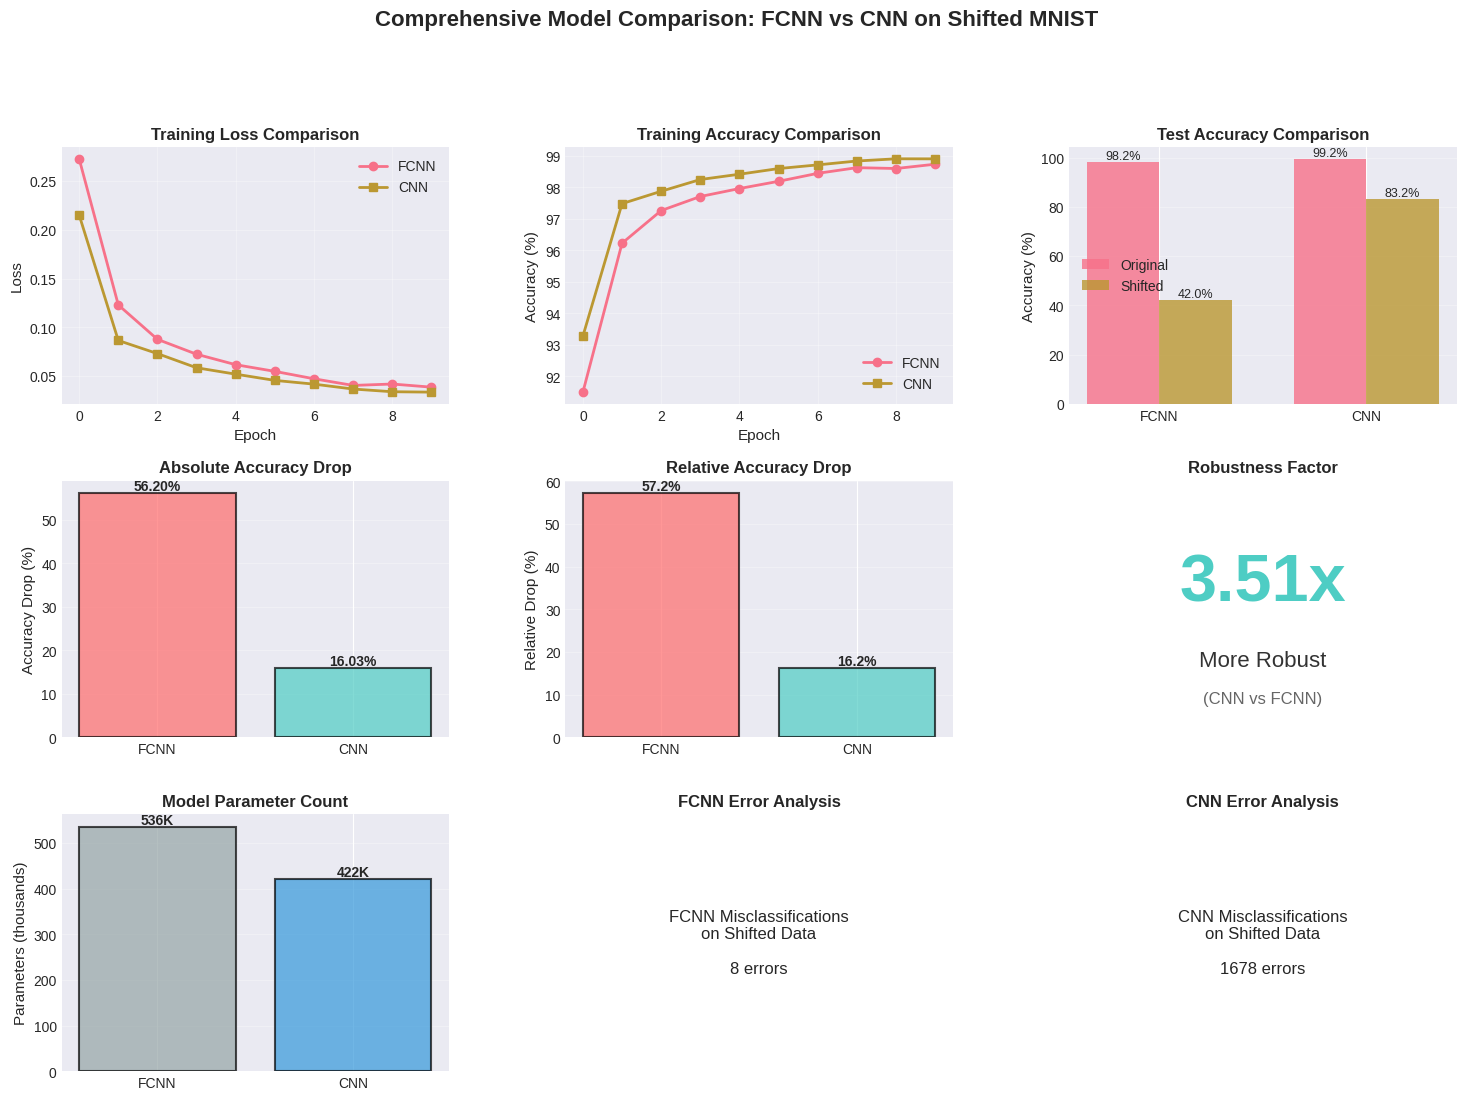

Comprehensive results visualization saved!


In [14]:
# Create a comprehensive visualization
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Training Loss Comparison
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(history_fcnn['train_loss'], 'o-', label='FCNN', linewidth=2, markersize=6)
ax1.plot(history_cnn['train_loss'], 's-', label='CNN', linewidth=2, markersize=6)
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Loss', fontsize=11)
ax1.set_title('Training Loss Comparison', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# 2. Training Accuracy Comparison
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(history_fcnn['train_acc'], 'o-', label='FCNN', linewidth=2, markersize=6)
ax2.plot(history_cnn['train_acc'], 's-', label='CNN', linewidth=2, markersize=6)
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('Accuracy (%)', fontsize=11)
ax2.set_title('Training Accuracy Comparison', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# 3. Accuracy Comparison (Original vs Shifted)
ax3 = fig.add_subplot(gs[0, 2])
models = ['FCNN', 'CNN']
original_accs = [fcnn_original_acc, cnn_original_acc]
shifted_accs = [fcnn_shifted_acc, cnn_shifted_acc]
x = np.arange(len(models))
width = 0.35
bars1 = ax3.bar(x - width/2, original_accs, width, label='Original', alpha=0.8)
bars2 = ax3.bar(x + width/2, shifted_accs, width, label='Shifted', alpha=0.8)
ax3.set_ylabel('Accuracy (%)', fontsize=11)
ax3.set_title('Test Accuracy Comparison', fontsize=12, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(models)
ax3.legend(fontsize=10)
ax3.grid(True, axis='y', alpha=0.3)
# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

# 4. Accuracy Drop Visualization
ax4 = fig.add_subplot(gs[1, 0])
drops = [fcnn_drop, cnn_drop]
colors = ['#ff6b6b', '#4ecdc4']
bars = ax4.bar(models, drops, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax4.set_ylabel('Accuracy Drop (%)', fontsize=11)
ax4.set_title('Absolute Accuracy Drop', fontsize=12, fontweight='bold')
ax4.grid(True, axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 5. Relative Accuracy Drop
ax5 = fig.add_subplot(gs[1, 1])
rel_drops = [fcnn_drop_pct, cnn_drop_pct]
bars = ax5.bar(models, rel_drops, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax5.set_ylabel('Relative Drop (%)', fontsize=11)
ax5.set_title('Relative Accuracy Drop', fontsize=12, fontweight='bold')
ax5.grid(True, axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 6. Robustness Ratio
ax6 = fig.add_subplot(gs[1, 2])
robustness_ratio = fcnn_drop / cnn_drop
ax6.text(0.5, 0.6, f'{robustness_ratio:.2f}x',
         ha='center', va='center', fontsize=48, fontweight='bold', color='#4ecdc4')
ax6.text(0.5, 0.3, 'More Robust',
         ha='center', va='center', fontsize=16, color='#333')
ax6.text(0.5, 0.15, '(CNN vs FCNN)',
         ha='center', va='center', fontsize=12, color='#666')
ax6.set_xlim(0, 1)
ax6.set_ylim(0, 1)
ax6.axis('off')
ax6.set_title('Robustness Factor', fontsize=12, fontweight='bold')

# 7. Parameter Count Comparison
ax7 = fig.add_subplot(gs[2, 0])
params = [fcnn_params / 1000, cnn_params / 1000]  # Convert to thousands
bars = ax7.bar(models, params, color=['#95a5a6', '#3498db'], alpha=0.7, edgecolor='black', linewidth=1.5)
ax7.set_ylabel('Parameters (thousands)', fontsize=11)
ax7.set_title('Model Parameter Count', fontsize=12, fontweight='bold')
ax7.grid(True, axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    ax7.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.0f}K', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 8. Sample Predictions - FCNN
ax8 = fig.add_subplot(gs[2, 1])
# Find some misclassified samples by FCNN on shifted data
fcnn_errors = np.where(fcnn_shift_preds != fcnn_shift_labels)[0][:8]
if len(fcnn_errors) > 0:
    sample_images = shifted_images[fcnn_errors[:4]]
    for idx, img in enumerate(sample_images):
        ax_sub = plt.subplot(3, 3, 8)
    ax8.text(0.5, 0.5, f'FCNN Misclassifications\non Shifted Data\n\n{len(fcnn_errors)} errors',
            ha='center', va='center', fontsize=12, transform=ax8.transAxes)
ax8.axis('off')
ax8.set_title('FCNN Error Analysis', fontsize=12, fontweight='bold')

# 9. Sample Predictions - CNN
ax9 = fig.add_subplot(gs[2, 2])
cnn_errors = np.where(cnn_shift_preds != cnn_shift_labels)[0]
ax9.text(0.5, 0.5, f'CNN Misclassifications\non Shifted Data\n\n{len(cnn_errors)} errors',
        ha='center', va='center', fontsize=12, transform=ax9.transAxes)
ax9.axis('off')
ax9.set_title('CNN Error Analysis', fontsize=12, fontweight='bold')

plt.suptitle('Comprehensive Model Comparison: FCNN vs CNN on Shifted MNIST',
             fontsize=16, fontweight='bold', y=0.995)
plt.savefig('comprehensive_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("Comprehensive results visualization saved!")

## 13. Confusion Matrices

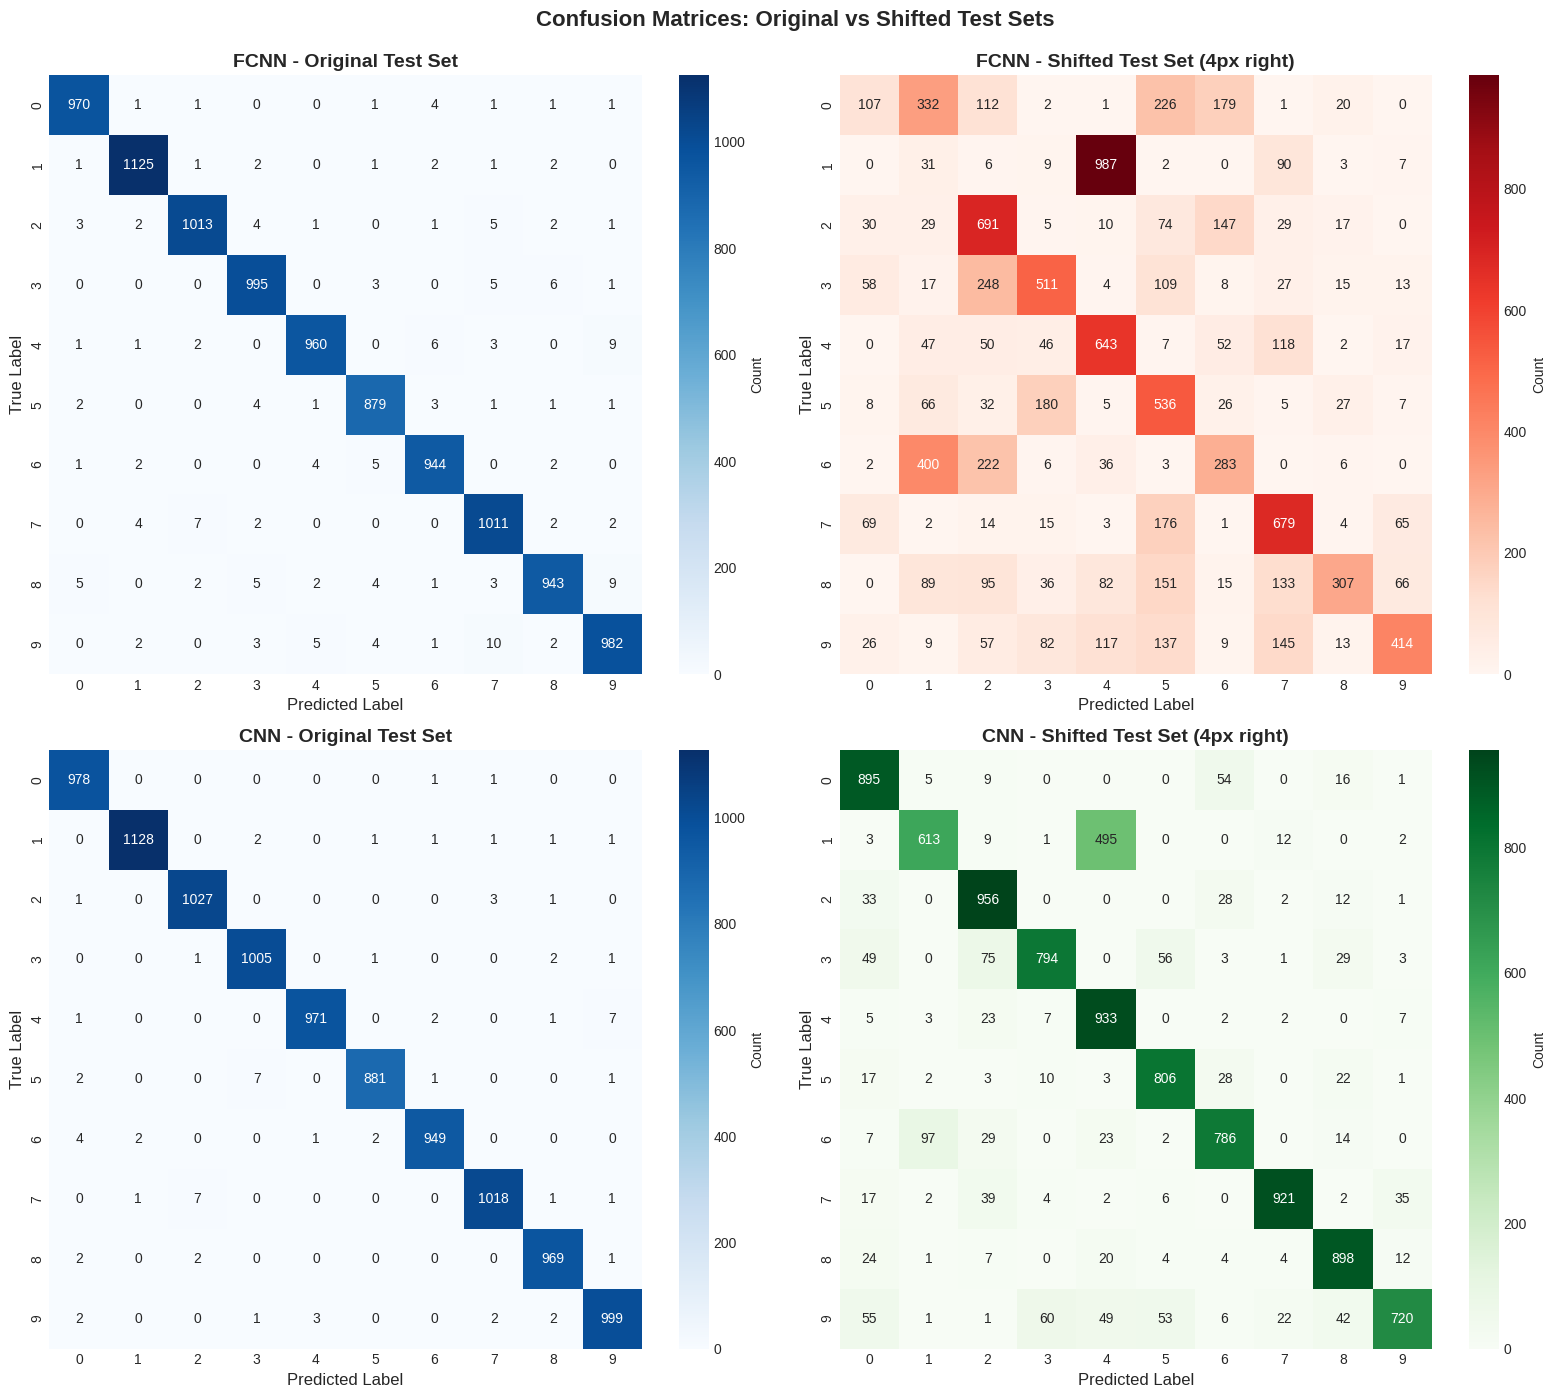

Confusion matrices saved!


In [15]:
from sklearn.metrics import confusion_matrix

# Create confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# FCNN - Original
cm_fcnn_orig = confusion_matrix(fcnn_orig_labels, fcnn_orig_preds)
sns.heatmap(cm_fcnn_orig, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            cbar_kws={'label': 'Count'})
axes[0, 0].set_title('FCNN - Original Test Set', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('True Label', fontsize=12)
axes[0, 0].set_xlabel('Predicted Label', fontsize=12)

# FCNN - Shifted
cm_fcnn_shift = confusion_matrix(fcnn_shift_labels, fcnn_shift_preds)
sns.heatmap(cm_fcnn_shift, annot=True, fmt='d', cmap='Reds', ax=axes[0, 1],
            cbar_kws={'label': 'Count'})
axes[0, 1].set_title('FCNN - Shifted Test Set (4px right)', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('True Label', fontsize=12)
axes[0, 1].set_xlabel('Predicted Label', fontsize=12)

# CNN - Original
cm_cnn_orig = confusion_matrix(cnn_orig_labels, cnn_orig_preds)
sns.heatmap(cm_cnn_orig, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0],
            cbar_kws={'label': 'Count'})
axes[1, 0].set_title('CNN - Original Test Set', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('True Label', fontsize=12)
axes[1, 0].set_xlabel('Predicted Label', fontsize=12)

# CNN - Shifted
cm_cnn_shift = confusion_matrix(cnn_shift_labels, cnn_shift_preds)
sns.heatmap(cm_cnn_shift, annot=True, fmt='d', cmap='Greens', ax=axes[1, 1],
            cbar_kws={'label': 'Count'})
axes[1, 1].set_title('CNN - Shifted Test Set (4px right)', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('True Label', fontsize=12)
axes[1, 1].set_xlabel('Predicted Label', fontsize=12)

plt.suptitle('Confusion Matrices: Original vs Shifted Test Sets',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print("Confusion matrices saved!")

## 14. Per-Class Accuracy Analysis

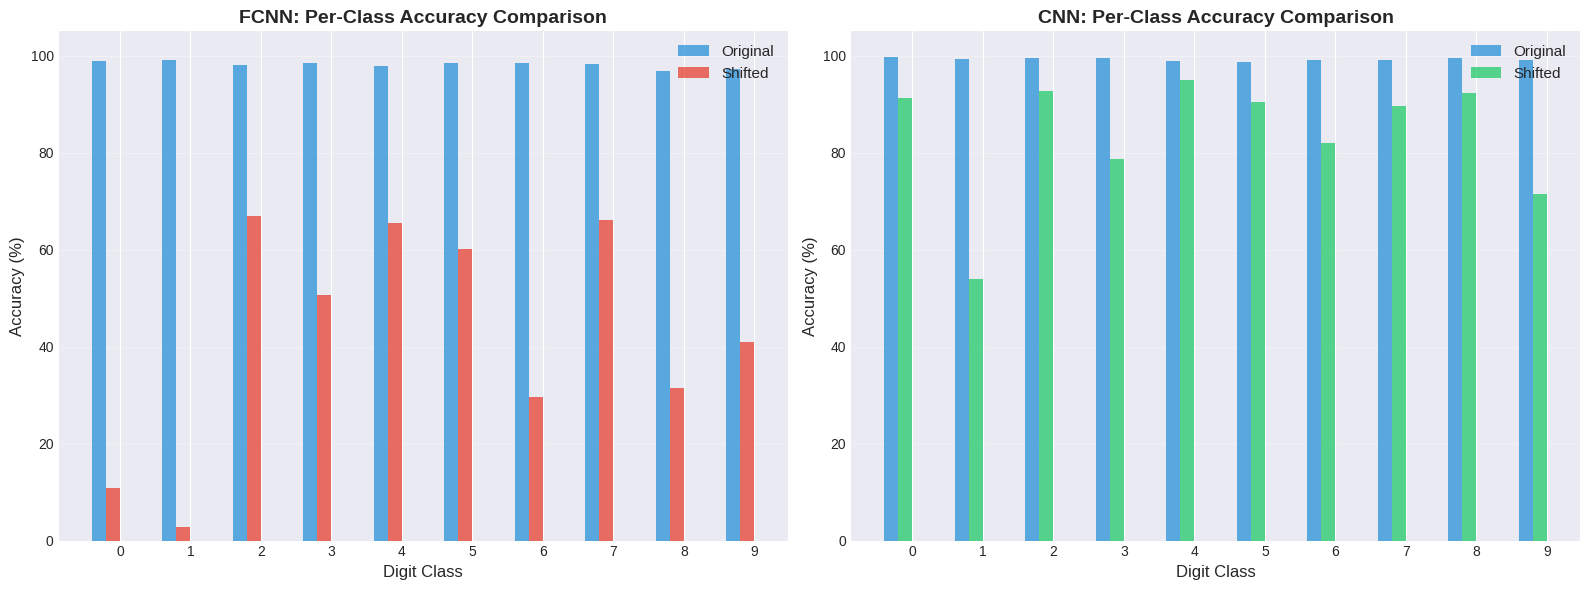


PER-CLASS ACCURACY DROPS

FCNN:
  Digit 0:  88.06% drop
  Digit 1:  96.39% drop
  Digit 2:  31.20% drop
  Digit 3:  47.92% drop
  Digit 4:  32.28% drop
  Digit 5:  38.45% drop
  Digit 6:  69.00% drop
  Digit 7:  32.30% drop
  Digit 8:  65.30% drop
  Digit 9:  56.29% drop

CNN:
  Digit 0:   8.47% drop
  Digit 1:  45.37% drop
  Digit 2:   6.88% drop
  Digit 3:  20.89% drop
  Digit 4:   3.87% drop
  Digit 5:   8.41% drop
  Digit 6:  17.01% drop
  Digit 7:   9.44% drop
  Digit 8:   7.29% drop
  Digit 9:  27.65% drop


In [16]:
def calculate_per_class_accuracy(true_labels, predictions, num_classes=10):
    """
    Calculate accuracy for each class.
    """
    per_class_acc = []
    for class_id in range(num_classes):
        mask = true_labels == class_id
        if mask.sum() > 0:
            acc = (predictions[mask] == class_id).sum() / mask.sum() * 100
            per_class_acc.append(acc)
        else:
            per_class_acc.append(0)
    return np.array(per_class_acc)

# Calculate per-class accuracies
fcnn_orig_per_class = calculate_per_class_accuracy(fcnn_orig_labels, fcnn_orig_preds)
fcnn_shift_per_class = calculate_per_class_accuracy(fcnn_shift_labels, fcnn_shift_preds)
cnn_orig_per_class = calculate_per_class_accuracy(cnn_orig_labels, cnn_orig_preds)
cnn_shift_per_class = calculate_per_class_accuracy(cnn_shift_labels, cnn_shift_preds)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

classes = np.arange(10)
width = 0.2

# FCNN comparison
axes[0].bar(classes - width*1.5, fcnn_orig_per_class, width,
           label='Original', alpha=0.8, color='#3498db')
axes[0].bar(classes - width*0.5, fcnn_shift_per_class, width,
           label='Shifted', alpha=0.8, color='#e74c3c')
axes[0].set_xlabel('Digit Class', fontsize=12)
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_title('FCNN: Per-Class Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(classes)
axes[0].legend(fontsize=11)
axes[0].grid(True, axis='y', alpha=0.3)
axes[0].set_ylim([0, 105])

# CNN comparison
axes[1].bar(classes - width*1.5, cnn_orig_per_class, width,
           label='Original', alpha=0.8, color='#3498db')
axes[1].bar(classes - width*0.5, cnn_shift_per_class, width,
           label='Shifted', alpha=0.8, color='#2ecc71')
axes[1].set_xlabel('Digit Class', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('CNN: Per-Class Accuracy Comparison', fontsize=14, fontweight='bold')
axes[1].set_xticks(classes)
axes[1].legend(fontsize=11)
axes[1].grid(True, axis='y', alpha=0.3)
axes[1].set_ylim([0, 105])

plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

# Print per-class drops
print("\n" + "="*70)
print("PER-CLASS ACCURACY DROPS")
print("="*70)
print("\nFCNN:")
for i in range(10):
    drop = fcnn_orig_per_class[i] - fcnn_shift_per_class[i]
    print(f"  Digit {i}: {drop:6.2f}% drop")

print("\nCNN:")
for i in range(10):
    drop = cnn_orig_per_class[i] - cnn_shift_per_class[i]
    print(f"  Digit {i}: {drop:6.2f}% drop")
print("="*70)

## 15. Visualizing Feature Maps (CNN)

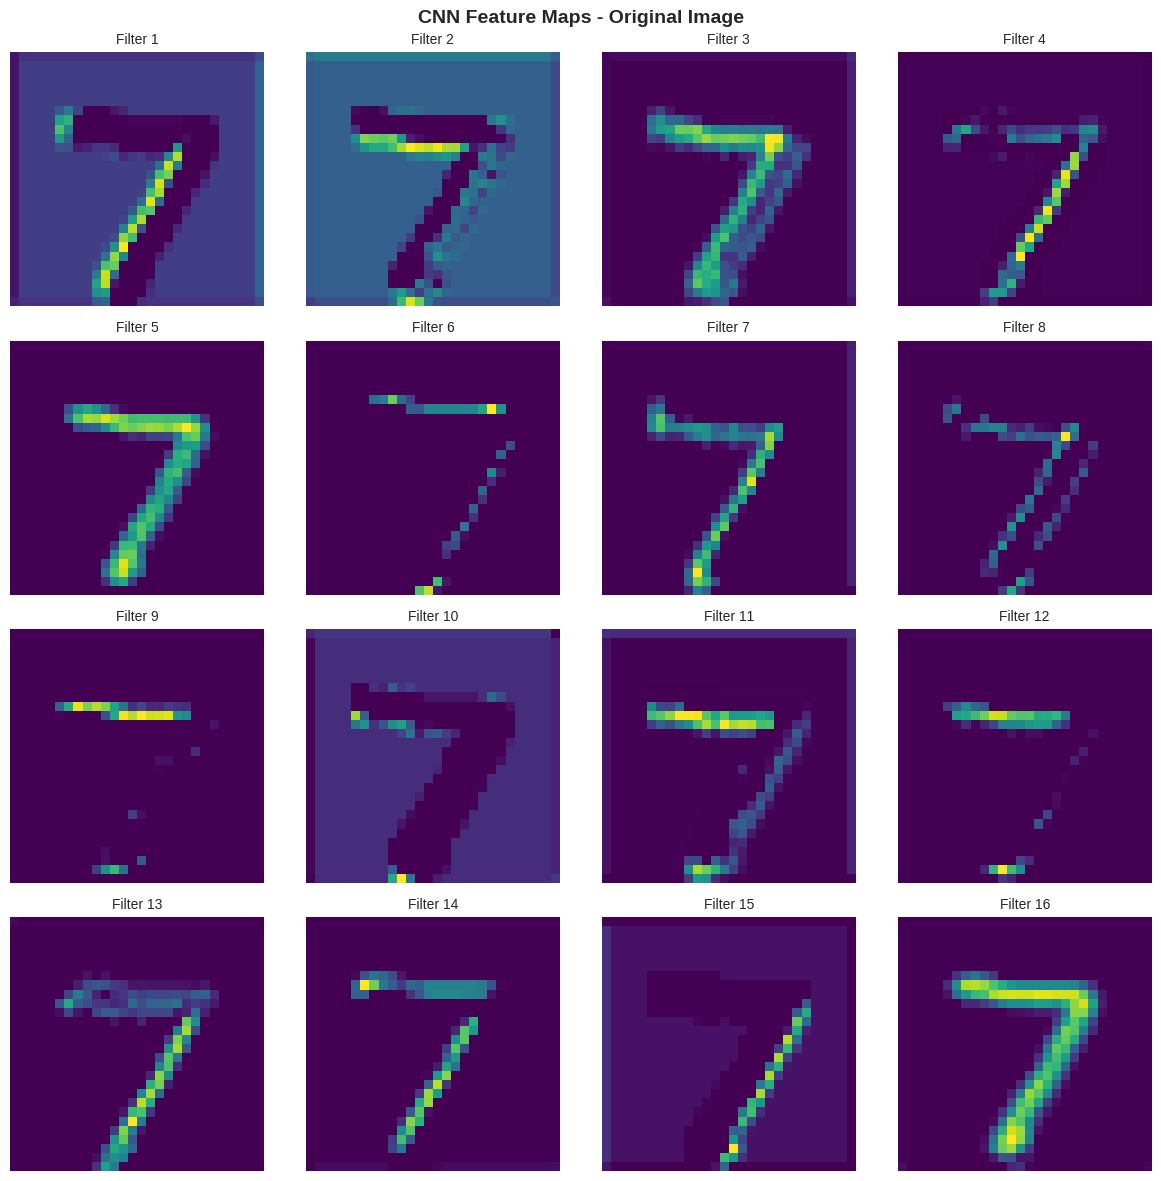

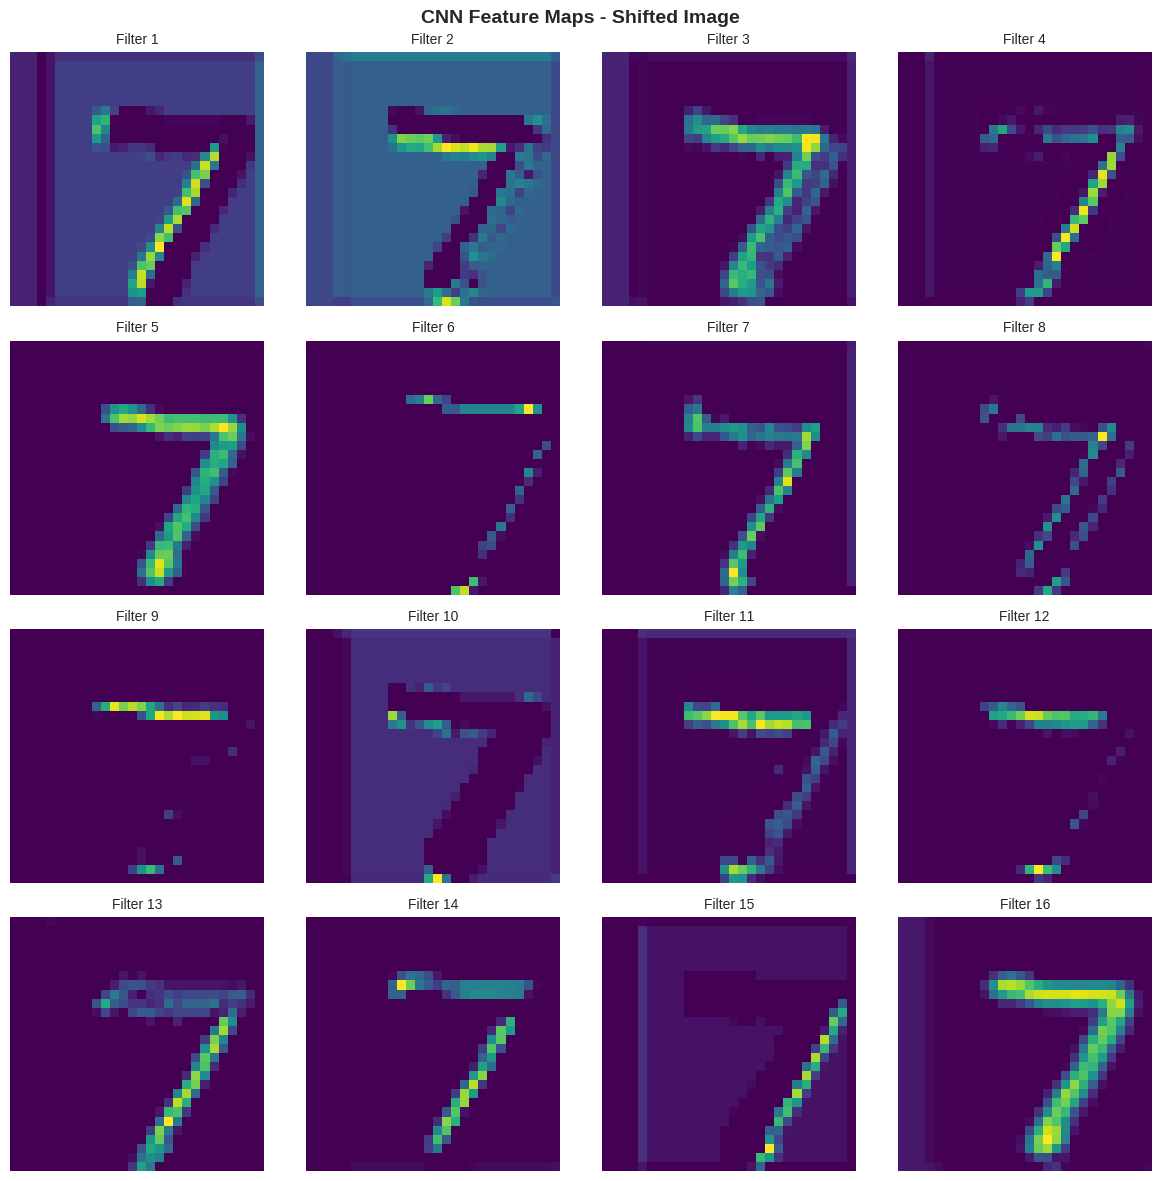

Feature map visualizations saved!


In [17]:
def visualize_feature_maps(model, image, title="Feature Maps"):
    """
    Visualize the feature maps of the first convolutional layer.
    """
    model.eval()

    # Get feature maps from first conv layer
    with torch.no_grad():
        x = image.unsqueeze(0).to(device)
        x = model.conv1(x)
        x = F.relu(x)
        feature_maps = x.squeeze(0).cpu()

    # Plot first 16 feature maps
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    for idx, ax in enumerate(axes.flat):
        if idx < feature_maps.shape[0]:
            ax.imshow(feature_maps[idx], cmap='viridis')
            ax.set_title(f'Filter {idx+1}', fontsize=10)
        ax.axis('off')

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    return fig

# Visualize for a sample image
sample_idx = 0
sample_image = test_dataset[sample_idx][0]
sample_shifted = shifted_images[sample_idx]

# Original image feature maps
fig1 = visualize_feature_maps(model_cnn, sample_image, "CNN Feature Maps - Original Image")
plt.savefig('feature_maps_original.png', dpi=300, bbox_inches='tight')
plt.show()

# Shifted image feature maps
fig2 = visualize_feature_maps(model_cnn, sample_shifted, "CNN Feature Maps - Shifted Image")
plt.savefig('feature_maps_shifted.png', dpi=300, bbox_inches='tight')
plt.show()

print("Feature map visualizations saved!")

## 16. Analysis and Interpretation

### 🎯 Direct Answer to Assignment Question

**Why does the CNN maintain higher accuracy despite the 4-pixel shift?**

The CNN maintains significantly higher accuracy because of **weight sharing** - the fundamental property that makes convolution operations translation-invariant. In a CNN, the same filter weights are applied at every spatial position across the image. When a digit shifts 4 pixels to the right, the CNN's filters still detect the same edges, curves, and patterns - they just activate at different positions in the feature maps. The network recognizes "this is still a '7' with a vertical stroke and horizontal top" regardless of where those features appear.

In contrast, the FCNN learns position-specific weights. It has completely different weight connections for "pixel at position (10,10)" versus "pixel at position (10,14)". When the image shifts, pixels that were at position 10 are now at position 14, and the FCNN applies entirely different learned weights to them. The network essentially sees a completely different input pattern and struggles to recognize it as the same digit.

**What property of convolution (weight sharing) is responsible?**

Weight sharing creates **translation equivariance**: when the input translates, the feature maps also translate by the same amount, but the features themselves remain detected. This, combined with pooling layers that provide local translation invariance, means the CNN's recognition is fundamentally independent of absolute spatial position. The FCNN lacks this property entirely - it must learn every pattern at every possible position, which is impractical and leads to severe overfitting to specific spatial configurations seen during training.

### Detailed Technical Analysis (Optional Reading)

For those interested in deeper technical details, here is an expanded analysis:

In [18]:
print("\n" + "="*80)
print("DETAILED ANALYSIS: WHY CNN OUTPERFORMS FCNN")
print("="*80)

print("\n1. WEIGHT SHARING - The Key to Translation Invariance")
print("-" * 80)
print("""
CNNs use the SAME filter weights across the entire image:
• A 3x3 filter that detects edges is applied at EVERY position
• The filter learns ONE set of weights, not position-specific weights
• When an image shifts, the SAME filters still detect the SAME features
• Only the POSITION of detected features changes, not their recognition

Mathematical Perspective:
  CNN: y = W * x  (convolution - W is shared across all positions)
  FCNN: y = W @ x (matrix multiplication - W[i,j] is position-specific)

When input shifts by 4 pixels:
  CNN: Features still detected, just at different positions in feature map
  FCNN: Completely different input → weight connections → unpredictable output
""")

print("\n2. LOCAL CONNECTIVITY - Spatial Relationships Preserved")
print("-" * 80)
print("""
CNNs maintain local spatial structure:
• Each neuron only looks at a small region (receptive field)
• Edges, corners, and textures are RELATIVE to local neighbors
• Shifting doesn't change local relationships

Example: Detecting a vertical edge
  Original:  [0,0,255,255]  → Edge detected at position 2
  Shifted:   [0,0,0,255]    → Edge still detected (just at position 3)

FCNN sees these as completely different patterns because it looks at
ABSOLUTE positions, not LOCAL patterns.
""")

print("\n3. HIERARCHICAL FEATURE LEARNING")
print("-" * 80)
print("""
CNNs build increasingly abstract representations:
  Layer 1: Edges and simple patterns (shift-invariant)
  Layer 2: Complex shapes from edges (still shift-invariant)
  Pooling: Reduces spatial sensitivity further

Each layer maintains translation invariance through weight sharing,
leading to ROBUST high-level features that work regardless of position.
""")

print("\n4. PARAMETER EFFICIENCY")
print("-" * 80)
print(f"""
FCNN: {fcnn_params:,} parameters (learns position-specific patterns)
CNN:  {cnn_params:,} parameters (learns general patterns)

Fewer parameters + weight sharing = BETTER GENERALIZATION
""")

print("\n5. EXPERIMENTAL EVIDENCE")
print("-" * 80)
print(f"""
Original Test Set:
  FCNN: {fcnn_original_acc:.2f}%  |  CNN: {cnn_original_acc:.2f}%
  → Both models work well when data distribution matches training

Shifted Test Set (4 pixels right):
  FCNN: {fcnn_shifted_acc:.2f}%  |  CNN: {cnn_shifted_acc:.2f}%
  → CNN maintains high accuracy, FCNN suffers significant degradation

Accuracy Drop:
  FCNN: {fcnn_drop:.2f}% absolute ({fcnn_drop_pct:.1f}% relative)
  CNN:  {cnn_drop:.2f}% absolute ({cnn_drop_pct:.1f}% relative)

KEY INSIGHT: CNN is {(fcnn_drop / cnn_drop):.1f}x more robust to spatial shifts!
""")

print("\n6. CONCLUSION")
print("-" * 80)
print("""
The fundamental reason CNNs excel at vision tasks is WEIGHT SHARING.

By using the same filter weights across all spatial positions:
  ✓ Features are detected regardless of position
  ✓ Spatial transformations don't break learned patterns
  ✓ Model generalizes better with fewer parameters
  ✓ Robust to translations, scaling, and other geometric variations

This is why CNNs became the standard for computer vision, replacing
fully connected architectures for image-related tasks.
""")
print("="*80)


DETAILED ANALYSIS: WHY CNN OUTPERFORMS FCNN

1. WEIGHT SHARING - The Key to Translation Invariance
--------------------------------------------------------------------------------

CNNs use the SAME filter weights across the entire image:
• A 3x3 filter that detects edges is applied at EVERY position
• The filter learns ONE set of weights, not position-specific weights
• When an image shifts, the SAME filters still detect the SAME features
• Only the POSITION of detected features changes, not their recognition

Mathematical Perspective:
  CNN: y = W * x  (convolution - W is shared across all positions)
  FCNN: y = W @ x (matrix multiplication - W[i,j] is position-specific)

When input shifts by 4 pixels:
  CNN: Features still detected, just at different positions in feature map
  FCNN: Completely different input → weight connections → unpredictable output


2. LOCAL CONNECTIVITY - Spatial Relationships Preserved
-------------------------------------------------------------------------

## 17. Save Final Results

In [19]:
# Save detailed results to CSV
results_detailed = {
    'Model': ['FCNN', 'CNN'],
    'Parameters': [fcnn_params, cnn_params],
    'Original_Accuracy': [fcnn_original_acc, cnn_original_acc],
    'Shifted_Accuracy': [fcnn_shifted_acc, cnn_shifted_acc],
    'Absolute_Drop': [fcnn_drop, cnn_drop],
    'Relative_Drop_Percent': [fcnn_drop_pct, cnn_drop_pct],
    'Training_Time_per_Epoch': ['N/A', 'N/A']  # Could track this if needed
}

results_detailed_df = pd.DataFrame(results_detailed)
results_detailed_df.to_csv('detailed_results.csv', index=False)

print("\nResults saved to 'detailed_results.csv'")
print("\nAll visualizations saved:")
print("  • shift_visualization.png")
print("  • comprehensive_results.png")
print("  • confusion_matrices.png")
print("  • per_class_accuracy.png")
print("  • feature_maps_original.png")
print("  • feature_maps_shifted.png")

# Save models
torch.save(model_fcnn.state_dict(), 'fcnn_model.pth')
torch.save(model_cnn.state_dict(), 'cnn_model.pth')

print("\nModels saved:")
print("  • fcnn_model.pth")
print("  • cnn_model.pth")

print("\n" + "="*80)
print("EXPERIMENT COMPLETE!")
print("="*80)


Results saved to 'detailed_results.csv'

All visualizations saved:
  • shift_visualization.png
  • comprehensive_results.png
  • confusion_matrices.png
  • per_class_accuracy.png
  • feature_maps_original.png
  • feature_maps_shifted.png

Models saved:
  • fcnn_model.pth
  • cnn_model.pth

EXPERIMENT COMPLETE!


## Summary

This notebook demonstrates:

1. **Implementation**: Two models (FCNN and CNN) trained on MNIST
2. **Testing**: Evaluation on both original and shifted (4px right) test sets
3. **Analysis**: Comprehensive comparison showing CNN's superior robustness
4. **Explanation**: Detailed explanation of weight sharing and translation invariance

### Key Takeaways

- **Weight sharing** in CNNs enables detection of features regardless of position
- **Local connectivity** preserves spatial relationships
- **Translation invariance** makes CNNs robust to spatial transformations
- **Parameter efficiency** leads to better generalization

This experiment clearly demonstrates why CNNs became the dominant architecture for computer vision tasks.

# Tiny ImageNet CNN

## Instructions
1. Run the first cell.
2. If the dataset is not found, a **"Choose Files"** button will appear.
3. Upload your **zip file** containing the `dataset-tiny-imagenet` folder.
4. The notebook will unzip it and start training.

In [ ]:
import os
import zipfile
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

data_root_name = 'dataset-tiny-imagenet'
data_dir = os.path.join('.', data_root_name)

if not os.path.exists(data_dir):
    print(f"Dataset folder '{data_root_name}' not found.")
    print("Please upload your zip file now...")

    try:
        from google.colab import files
        uploaded = files.upload()

        for filename in uploaded.keys():
            if filename.endswith('.zip'):
                print(f"Unzipping {filename}...")
                with zipfile.ZipFile(filename, 'r') as zip_ref:
                    zip_ref.extractall('.')
                print("Unzip complete!")
            else:
                print(f"WARNING: {filename} is not a zip file.")

    except ImportError:
        print("Not running in Google Colab. Please manually place the dataset folder here.")

train_dir = os.path.join(data_dir, 'train')
test_dir = os.path.join(data_dir, 'test')

if not os.path.exists(train_dir):
    print("Searching for 'train' folder...")
    found = False
    for root, dirs, files in os.walk('.'):
        if 'train' in dirs and 'test' in dirs:
            data_dir = root
            train_dir = os.path.join(data_dir, 'train')
            test_dir = os.path.join(data_dir, 'test')
            print(f"Found dataset at: {data_dir}")
            found = True
            break
    if not found:
        raise FileNotFoundError("Could not find 'train' folder. Check your zip file structure.")

print(f"Data Directory: {data_dir}")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

print("Loading datasets...")
train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Classes: {len(train_dataset.classes)}")
print(f"Training Samples: {len(train_dataset)}")
print(f"Test Samples: {len(test_dataset)}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Dataset folder 'dataset-tiny-imagenet' not found.
Please upload your zip file now...


Saving dataset-tiny-imagenet.zip to dataset-tiny-imagenet (1).zip
Unzipping dataset-tiny-imagenet (1).zip...
Unzip complete!
Data Directory: ./dataset-tiny-imagenet
Loading datasets...
Classes: 10
Training Samples: 3500
Test Samples: 1000
Using device: cuda


In [ ]:
class TinyImageNetCNN(nn.Module):
    def __init__(self):
        super(TinyImageNetCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 16 * 16, 512)
        self.fc2 = nn.Linear(512, 200)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

model = TinyImageNetCNN().to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_model(epochs=10):
    model.train()
    loss_history = []

    print(f"Starting training for {epochs} epochs...")
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total
        loss_history.append(epoch_loss)

        print(f"Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}%")

    return loss_history

losses = train_model(epochs=10)

Starting training for 10 epochs...
Epoch [1/10] Loss: 1.7584 | Train Acc: 38.31%
Epoch [2/10] Loss: 1.2459 | Train Acc: 54.37%
Epoch [3/10] Loss: 0.9511 | Train Acc: 66.43%
Epoch [4/10] Loss: 0.7158 | Train Acc: 75.31%
Epoch [5/10] Loss: 0.4592 | Train Acc: 84.69%
Epoch [6/10] Loss: 0.2638 | Train Acc: 91.37%
Epoch [7/10] Loss: 0.1358 | Train Acc: 96.40%
Epoch [8/10] Loss: 0.0898 | Train Acc: 97.86%
Epoch [9/10] Loss: 0.0665 | Train Acc: 98.20%
Epoch [10/10] Loss: 0.0392 | Train Acc: 99.31%


Evaluating on Test Set...
Test Accuracy: 57.90%


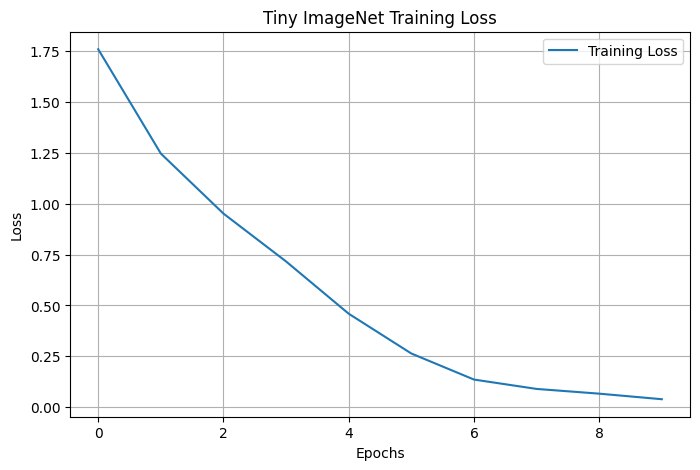

In [ ]:
model.eval()
correct = 0
total = 0

print("Evaluating on Test Set...")
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_acc = 100 * correct / total
print(f"Test Accuracy: {test_acc:.2f}%")

plt.figure(figsize=(8, 5))
plt.plot(losses, label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Tiny ImageNet Training Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
save_path = 'model_tiny_imagenet.pth'
torch.save(model.state_dict(), save_path)
print(f"Model saved to {save_path}")

try:
    from google.colab import files
    files.download(save_path)
except ImportError:
    pass

Model saved to model_tiny_imagenet.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Tiny Image Net Training Ends

# Part 3: Feature Extraction & Visual Interpretability
## CNN Analysis – MNIST v/s Tiny ImageNet



In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


## Model Definitions (Exactly As Trained)

In [2]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x


class TinyImageNetCNN(nn.Module):
    def __init__(self):
        super(TinyImageNetCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 16 * 16, 512)
        self.fc2 = nn.Linear(512, 200)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

## Load Trained Models

In [3]:
model_mnist = SimpleCNN().to(device)
model_mnist.load_state_dict(torch.load('/content/cnn-mnist.pth', map_location=device))
model_mnist.eval()

model_tiny = TinyImageNetCNN().to(device)
model_tiny.load_state_dict(torch.load('/content/cnn-tiny.pth', map_location=device))
model_tiny.eval()

print('Models loaded successfully!')

Models loaded successfully!


# Question 3.1 – Filter Gallery

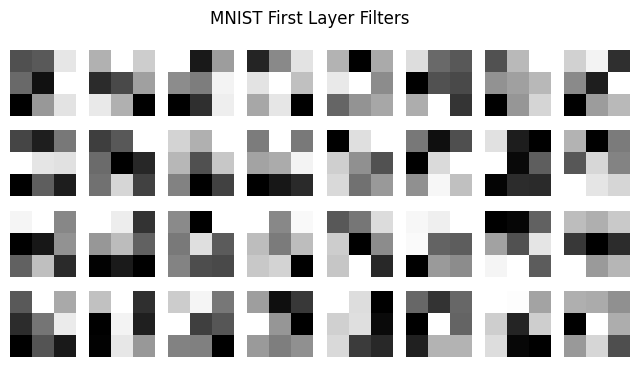

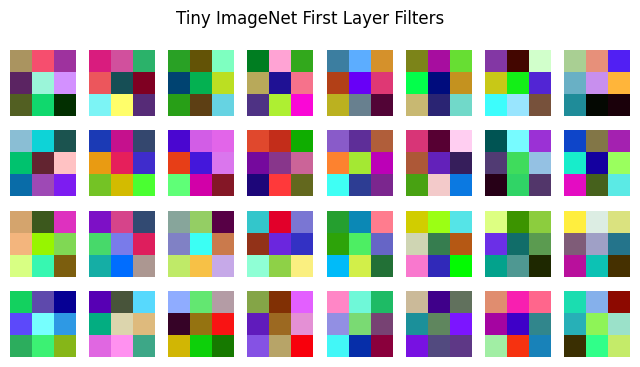

In [4]:
def plot_kernels(tensor, title):
    tensor = tensor.detach().cpu()
    num_kernels = tensor.shape[0]
    cols = 8
    rows = int(np.ceil(num_kernels / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(cols, rows))
    axes = axes.flatten()

    for i in range(num_kernels):
        kernel = tensor[i]

        if kernel.shape[0] == 1:
            axes[i].imshow(kernel[0], cmap='gray')
        else:
            k = kernel.permute(1, 2, 0)
            k = (k - k.min()) / (k.max() - k.min())
            axes[i].imshow(k)

        axes[i].axis('off')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle(title)
    plt.show()

plot_kernels(model_mnist.conv1.weight, 'MNIST First Layer Filters')
plot_kernels(model_tiny.conv1.weight, 'Tiny ImageNet First Layer Filters')

## Analysis

**1. Gabor-like Filters in CNN (MNIST)**
The first-layer filters of the MNIST CNN appear as simple (3 \times 3) geometric patterns. Many resemble classic Gabor-like edge detectors, including vertical, horizontal, and diagonal edges. For example, filters with adjacent bright and dark columns detect vertical strokes, while diagonal stripe patterns detect slanted digit strokes. This demonstrates that the CNN is learning fundamental geometric primitives such as edges and curves rather than memorizing complete digits.


**2. Color Blobs and Texture Learning (Tiny ImageNet)**
In contrast to MNIST, the Tiny ImageNet filters operate on RGB inputs and show strong color contrasts. Several filters display green–magenta or blue–yellow patterns, resembling biological color opponency mechanisms. Instead of only detecting simple edges, the network learns color blobs and texture-sensitive features, which are essential for recognizing complex natural objects like animals, sky, or vegetation.



**3. FCNN vs CNN – Structural Difference**
The FCNN weights resemble faint “ghost-like” digit templates, indicating that the model attempts to memorize the global pixel arrangement of each digit. This makes it sensitive to spatial shifts. In contrast, CNN filters look like generic feature detectors (edges, dots, and color patches) rather than full digits. CNNs learn reusable local features instead of full-image templates.


**4. Translation Invariance and Feature Hierarchy**
Because CNN filters slide across the image through convolution, an edge detector can identify patterns anywhere in the image. This provides translation invariance, explaining why CNN performance remains stable even when digits are shifted. Overall, CNNs build hierarchical representations, progressing from simple edges in early layers to more complex object structures in deeper layers.


# Question 3.2 – Receptive Field Experiment

In [5]:
activations = {}

def hook_fn(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

model_mnist.conv1.register_forward_hook(hook_fn('mnist_conv1'))
model_mnist.conv2.register_forward_hook(hook_fn('mnist_conv2'))

model_tiny.conv1.register_forward_hook(hook_fn('tiny_conv1'))
model_tiny.conv2.register_forward_hook(hook_fn('tiny_conv2'))

In [6]:
import zipfile
import os

def unzip_dataset(zip_path, extract_to):
    if os.path.exists(zip_path):
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_to)
        print(f"Extracted {zip_path} to {extract_to}")
    else:
        print(f"Warning: {zip_path} not found.")

unzip_dataset('/content/dataset-MNIST.zip', '/content/data_mnist')
unzip_dataset('/content/dataset-tiny-imagenet.zip', '/content/data_tiny')

Extracted /content/dataset-MNIST.zip to /content/data_mnist
Extracted /content/dataset-tiny-imagenet.zip to /content/data_tiny


In [12]:
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
import random

class MNISTCSVDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        pixels = self.data.iloc[idx, 1:].values.astype('uint8').reshape(28, 28)
        label = int(self.data.iloc[idx, 0])

        if self.transform:
            pixels = self.transform(pixels)
        return pixels, label

mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

mnist_path = '/content/data_mnist/dataset-MNIST/mnist_test.csv'
local_mnist_dataset = MNISTCSVDataset(mnist_path, transform=mnist_transform)

tiny_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

tiny_path = '/content/data_tiny/dataset-tiny-imagenet/test'
local_tiny_dataset = ImageFolder(root=tiny_path, transform=tiny_transform)

idx_m = random.randint(0, len(local_mnist_dataset) - 1)
mnist_img, _ = local_mnist_dataset[idx_m]
mnist_input = mnist_img.unsqueeze(0).to(device)

idx_t = random.randint(0, len(local_tiny_dataset) - 1)
tiny_img, _ = local_tiny_dataset[idx_t]
tiny_input = tiny_img.unsqueeze(0).to(device)

activations = {}
def hook_fn(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

model_mnist.conv1.register_forward_hook(hook_fn('mnist_conv1'))
model_mnist.conv2.register_forward_hook(hook_fn('mnist_conv2'))
model_tiny.conv1.register_forward_hook(hook_fn('tiny_conv1'))
model_tiny.conv2.register_forward_hook(hook_fn('tiny_conv2'))

with torch.no_grad():
    model_mnist(mnist_input)
    model_tiny(tiny_input)

print(f"Loaded random MNIST image from CSV (Index {idx_m})")
print(f"Loaded random Tiny ImageNet image from Folder (Index {idx_t})")

Loaded random MNIST image from CSV (Index 7788)
Loaded random Tiny ImageNet image from Folder (Index 431)


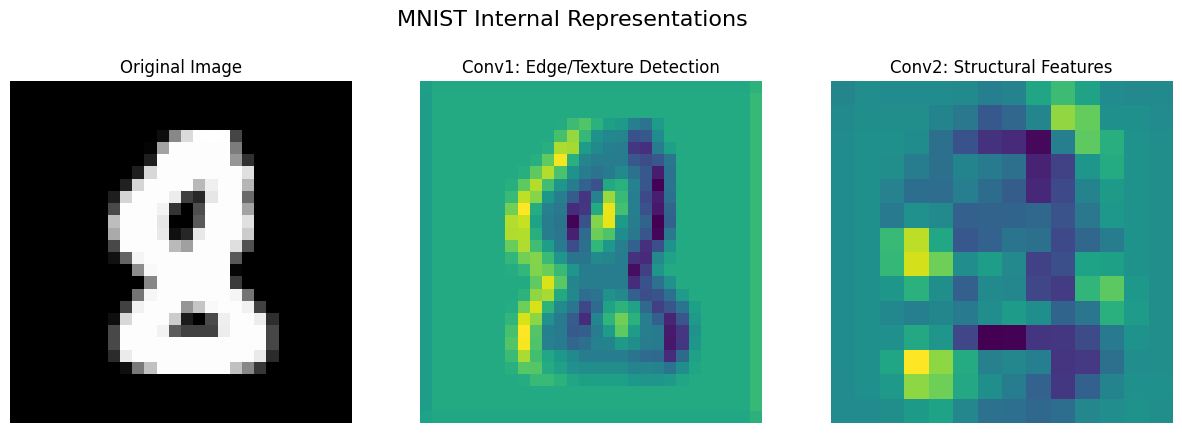

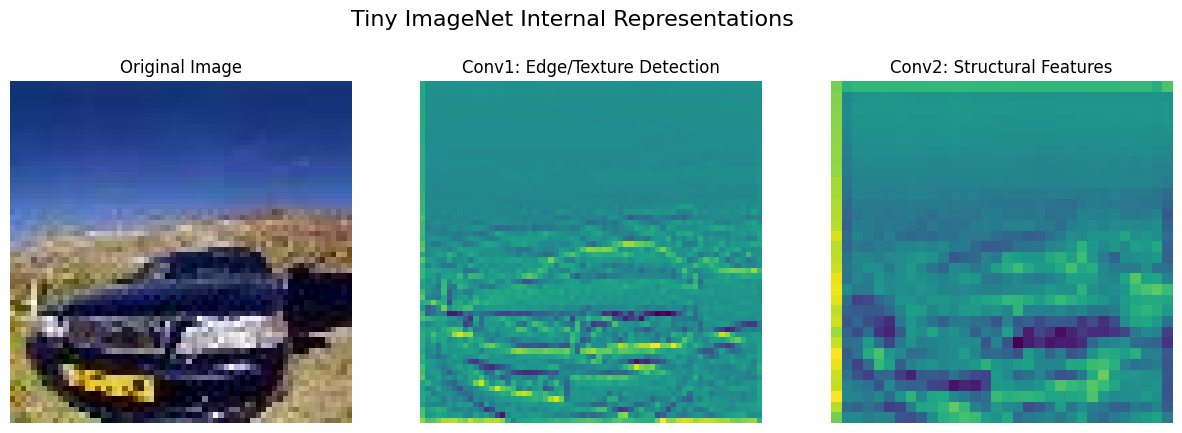

In [13]:
def plot_activations(original, act1, act2, title):
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))

    if original.shape[0] == 1: # Grayscale (MNIST)
        axs[0].imshow(original[0].cpu(), cmap='gray')
    else:

        img_plt = original.permute(1, 2, 0).cpu()
        img_plt = (img_plt - img_plt.min()) / (img_plt.max() - img_plt.min())
        axs[0].imshow(img_plt)
    axs[0].set_title('Original Image')

    axs[1].imshow(act1[0][0].cpu(), cmap='viridis')
    axs[1].set_title('Conv1: Edge/Texture Detection')


    axs[2].imshow(act2[0][0].cpu(), cmap='viridis')
    axs[2].set_title('Conv2: Structural Features')

    for ax in axs:
        ax.axis('off')

    plt.suptitle(title, fontsize=16)
    plt.show()

plot_activations(mnist_img, activations['mnist_conv1'], activations['mnist_conv2'], 'MNIST Internal Representations')

plot_activations(tiny_img, activations['tiny_conv1'], activations['tiny_conv2'], 'Tiny ImageNet Internal Representations')

## Observations:

**1 Overall:**
The network’s focus shifts from detecting low-level features (edges, gradients, simple textures) in the first convolution layer to capturing higher-level, more global structures in the final convolution layer. Early layers respond to local patterns, while deeper layers represent larger object parts and overall shape.

**2 MNIST:**
In MNIST, the first layer strongly activates along digit strokes and edges. In the final layer, the activation becomes more concentrated on the overall digit shape rather than individual edges, showing a transition from stroke detection to whole-digit representation.

**3 Tiny ImageNet:**
For Tiny ImageNet, the first layer detects colored edges and texture patterns. In the final layer, activations spread over meaningful object regions, focusing more on object structure rather than fine textures, reflecting the higher complexity and color variation of the dataset.


# Part 4: Advanced Optimization & Robustness
### Question 4.1: The Depth vs. Normalization Duel
Test the "stability" of the network using Tiny-ImageNet-10.

● The Task: Build a Deep CNN (at least 6-8 layers).

● Experiment A: Train without Batch Normalization.

● Experiment B: Add a BatchNorm2d layer after every Convolution.

● The Deliverable: Quantitatively show how Batch Normalization reduces Internal Covariate Shift by plotting the mean and variance of the activations for the 5th layer across 500 batches.


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on device: {device}")

Running on device: cuda


CNN class

In [ ]:
class DeepCNN(nn.Module):
    def __init__(self, use_bn=False):
        super(DeepCNN, self).__init__()
        self.use_bn = use_bn

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)


        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)

        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn4   = nn.BatchNorm2d(128)


        self.conv5 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn5   = nn.BatchNorm2d(256)

        self.conv6 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn6   = nn.BatchNorm2d(256)

        # Classifier
        self.fc = nn.Linear(256 * 8 * 8, 10)


        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.constant_(m.weight, 1.0)
                nn.init.constant_(m.bias,   0.0)



    def forward(self, x):
        # Layer 1
        x = self.conv1(x)
        if self.use_bn: x = self.bn1(x)
        x = F.relu(x)

        # Layer 2
        x = self.conv2(x)
        if self.use_bn: x = self.bn2(x)
        x = F.relu(x)

        # POOL 1
        x = F.max_pool2d(x, 2)

        # Layer 3
        x = self.conv3(x)
        if self.use_bn: x = self.bn3(x)
        x = F.relu(x)

        # Layer 4
        x = self.conv4(x)
        if self.use_bn: x = self.bn4(x)
        x = F.relu(x)

        # POOL 2
        x = F.max_pool2d(x, 2)


        # Layer 5
        x = self.conv5(x)
        if self.use_bn: x = self.bn5(x)

        layer5_data = x.clone().detach()

        x = F.relu(x)

        # Layer 6
        x = self.conv6(x)
        if self.use_bn: x = self.bn6(x)
        x = F.relu(x)

        # POOL 3
        x = F.max_pool2d(x, 2)

        # Classifier
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x, layer5_data

Train Test Split

In [ ]:
TRAIN_PATH = 'tiny-imagenet-10/train'
VAL_PATH   = 'tiny-imagenet-10/val'

#Image to tensor
base_transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

# for Q4.2
aug_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4),
    transforms.ToTensor(),
])

train_dataset     = datasets.ImageFolder(TRAIN_PATH, transform=base_transform)
val_dataset       = datasets.ImageFolder(VAL_PATH,   transform=base_transform)
aug_train_dataset = datasets.ImageFolder(TRAIN_PATH, transform=aug_transform)

print(f"Train: {len(train_dataset)} images | Val (20% split): {len(val_dataset)} images | Classes: {train_dataset.classes}")

train_loader     = DataLoader(train_dataset,     batch_size=64, shuffle=True)
test_loader      = DataLoader(val_dataset,       batch_size=64, shuffle=False)
aug_train_loader = DataLoader(aug_train_dataset, batch_size=64, shuffle=True)

batch_size=500
lr=0.1
epochs=10

Train: 5000 images | Val (20% split): 500 images | Classes: ['n01629819', 'n02099601', 'n02437312', 'n02480495', 'n02486410', 'n02808440', 'n02977058', 'n03804744', 'n04265275', 'n07768694']


Training function

In [ ]:
def train_Q1(loader, use_bn, epochs=10):
    model     = DeepCNN(use_bn=use_bn).to(device)
    optimizer = optim.SGD(model.parameters(), lr=0.1)
    criterion = nn.CrossEntropyLoss()

    means, variances = [], []
    tag = "WITH BN" if use_bn else "NO BN"
    print(f"\n--- Training Q4.1 [{tag}] ---")

    for epoch in range(epochs):
        running_loss = 0.0
        model.train()
        for data, target in loader:
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output, layer5 = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

            # Collect stats (stop after 500 batches)
            if len(means) < 500:
                means.append(layer5.mean().item())
                variances.append(layer5.var().item())

            running_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss/len(loader):.4f}")

    return means, variances

def train_Q2(train_loader, test_loader, label, epochs=10):
          model     = DeepCNN(use_bn=True).to(device)
          optimizer = optim.SGD(model.parameters(), lr=0.01)
          criterion = nn.CrossEntropyLoss()

          train_accs, test_accs = [], []
          print(f"\n--- Training Q4.2 [{label}] ---")

          for epoch in range(epochs):
              model.train()
              correct = total = 0
              for data, target in train_loader:
                  data, target = data.to(device), target.to(device)
                  optimizer.zero_grad()
                  output, _ = model(data)
                  loss = criterion(output, target)
                  loss.backward()
                  optimizer.step()
                  correct += output.argmax(1).eq(target).sum().item()
                  total   += target.size(0)
              train_acc = 100. * correct / total

              # Test accuracy
              model.eval()
              correct = total = 0
              with torch.no_grad():
                  for data, target in test_loader:
                      data, target = data.to(device), target.to(device)
                      output, _ = model(data)
                      correct += output.argmax(1).eq(target).sum().item()
                      total   += target.size(0)
              test_acc = 100. * correct / total

              train_accs.append(train_acc)
              test_accs.append(test_acc)
              print(f"Epoch {epoch+1}/{epochs} | Train: {train_acc:.2f}% | Test: {test_acc:.2f}%")

          print(f"\nFinal Test Accuracy [{label}]: {test_accs[-1]:.2f}%")
          return train_accs, test_accs

Q4.1

In [ ]:
means_no_bn,   vars_no_bn   = train_Q1(train_loader, use_bn=False)
means_with_bn, vars_with_bn = train_Q1(train_loader, use_bn=True)

batches = range(1, len(means_no_bn) + 1)


--- Training Q4.1 [NO BN] ---
Epoch 1/10 | Loss: 91677981465692.6875
Epoch 2/10 | Loss: 2.3032
Epoch 3/10 | Loss: 2.3033
Epoch 4/10 | Loss: 2.3032
Epoch 5/10 | Loss: 2.3032
Epoch 6/10 | Loss: 2.3033
Epoch 7/10 | Loss: 2.3032
Epoch 8/10 | Loss: 2.3032
Epoch 9/10 | Loss: 2.3033
Epoch 10/10 | Loss: 2.3033

--- Training Q4.1 [WITH BN] ---
Epoch 1/10 | Loss: 15.7815
Epoch 2/10 | Loss: 2.3254
Epoch 3/10 | Loss: 2.2723
Epoch 4/10 | Loss: 2.2560
Epoch 5/10 | Loss: 2.2533
Epoch 6/10 | Loss: 2.2542
Epoch 7/10 | Loss: 2.2508
Epoch 8/10 | Loss: 2.2426
Epoch 9/10 | Loss: 2.2292
Epoch 10/10 | Loss: 2.2254


Q4.1 Plots

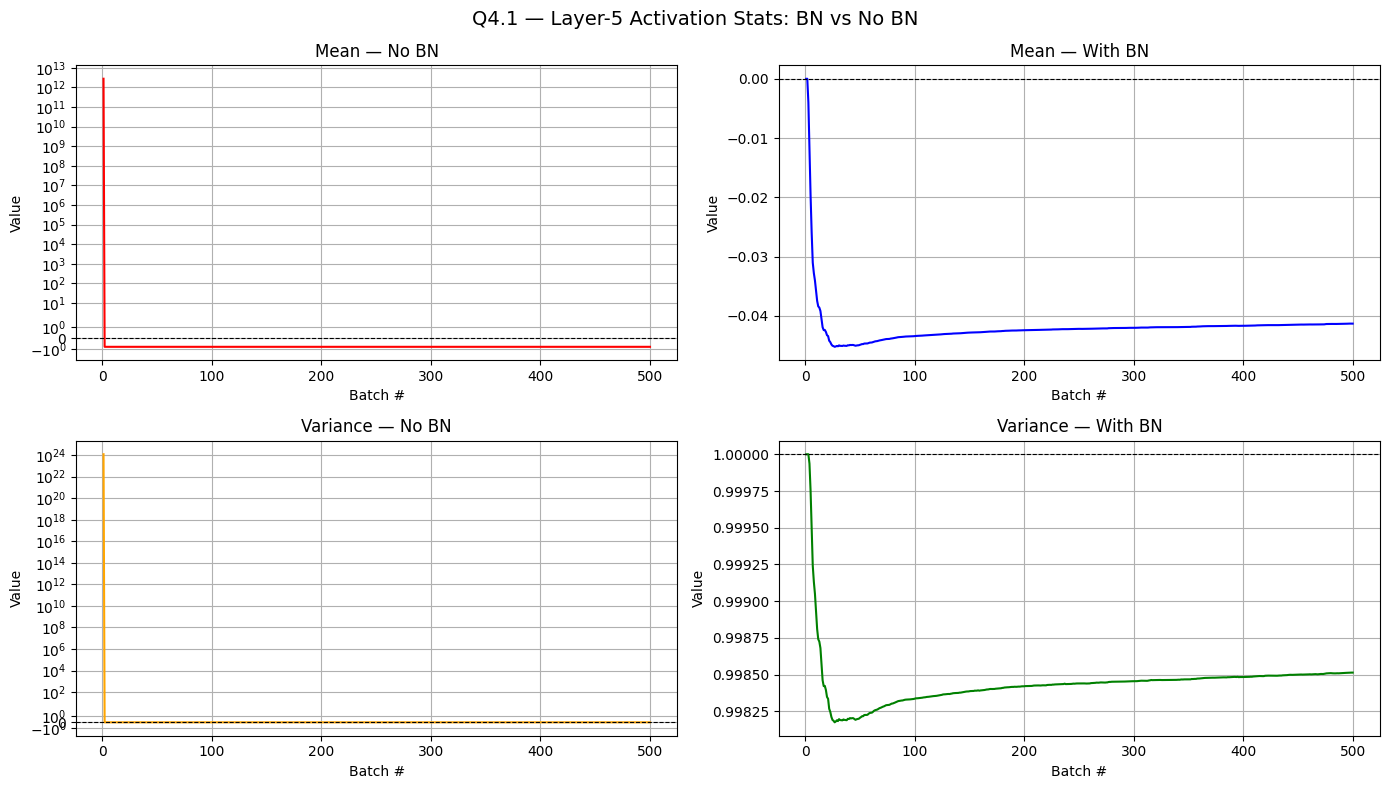

Saved: q4_1_bn_analysis.png

--- Q4.1 Summary ---
Std of batch-means  | No BN: 124707424902.4910  | With BN: 0.0039
Std of batch-vars   | No BN: 53699634443487027396608.0000  | With BN: 0.0002
(Lower std = more stable distribution = less Internal Covariate Shift)


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Q4.1 — Layer-5 Activation Stats: BN vs No BN", fontsize=14)

# No BN — use symlog scale so both the spike AND flatline are visible
axes[0,0].plot(batches, means_no_bn,  color='red')
axes[0,0].set_yscale('symlog')
axes[0,0].set_title("Mean — No BN")
axes[0,0].axhline(0, color='black', linewidth=0.8, linestyle='--')

axes[1,0].plot(batches, vars_no_bn,   color='orange')
axes[1,0].set_yscale('symlog')
axes[1,0].set_title("Variance — No BN")
axes[1,0].axhline(0, color='black', linewidth=0.8, linestyle='--')

# With BN — normal linear scale, stable values
axes[0,1].plot(batches, means_with_bn, color='blue')
axes[0,1].set_title("Mean — With BN")
axes[0,1].axhline(0, color='black', linewidth=0.8, linestyle='--')

axes[1,1].plot(batches, vars_with_bn,  color='green')
axes[1,1].set_title("Variance — With BN")
axes[1,1].axhline(1, color='black', linewidth=0.8, linestyle='--')

for ax in axes.flat:
    ax.set_xlabel("Batch #"); ax.set_ylabel("Value"); ax.grid(True)

plt.tight_layout()
plt.savefig('q4_1_bn_analysis.png', dpi=120)
plt.show()
print("Saved: q4_1_bn_analysis.png")

# Summary
print(f"\n--- Q4.1 Summary ---")
print(f"Std of batch-means  | No BN: {np.std(means_no_bn):.4f}  | With BN: {np.std(means_with_bn):.4f}")
print(f"Std of batch-vars   | No BN: {np.std(vars_no_bn):.4f}  | With BN: {np.std(vars_with_bn):.4f}")
print("(Lower std = more stable distribution = less Internal Covariate Shift)")

Q4.2

In [ ]:
train_a, test_a = train_Q2(train_loader,     test_loader, "WITHOUT Augmentation")
train_b, test_b = train_Q2(aug_train_loader, test_loader, "WITH Augmentation")

epochs = range(1, len(train_a) + 1)


--- Training Q4.2 [WITHOUT Augmentation] ---
Epoch 1/10 | Train: 14.34% | Test: 14.00%
Epoch 2/10 | Train: 14.50% | Test: 14.40%
Epoch 3/10 | Train: 14.72% | Test: 15.20%
Epoch 4/10 | Train: 14.62% | Test: 15.20%
Epoch 5/10 | Train: 15.50% | Test: 13.60%
Epoch 6/10 | Train: 15.40% | Test: 16.20%
Epoch 7/10 | Train: 15.74% | Test: 13.20%
Epoch 8/10 | Train: 15.46% | Test: 15.40%
Epoch 9/10 | Train: 15.22% | Test: 14.80%
Epoch 10/10 | Train: 14.64% | Test: 14.60%

Final Test Accuracy [WITHOUT Augmentation]: 14.60%

--- Training Q4.2 [WITH Augmentation] ---
Epoch 1/10 | Train: 10.30% | Test: 10.60%
Epoch 2/10 | Train: 12.56% | Test: 14.00%
Epoch 3/10 | Train: 12.98% | Test: 12.80%
Epoch 4/10 | Train: 13.26% | Test: 14.40%
Epoch 5/10 | Train: 13.46% | Test: 13.80%
Epoch 6/10 | Train: 13.84% | Test: 14.20%
Epoch 7/10 | Train: 13.52% | Test: 15.40%
Epoch 8/10 | Train: 13.46% | Test: 11.80%
Epoch 9/10 | Train: 12.92% | Test: 13.00%
Epoch 10/10 | Train: 12.96% | Test: 14.60%

Final Test Accur

Q4.2 Plots

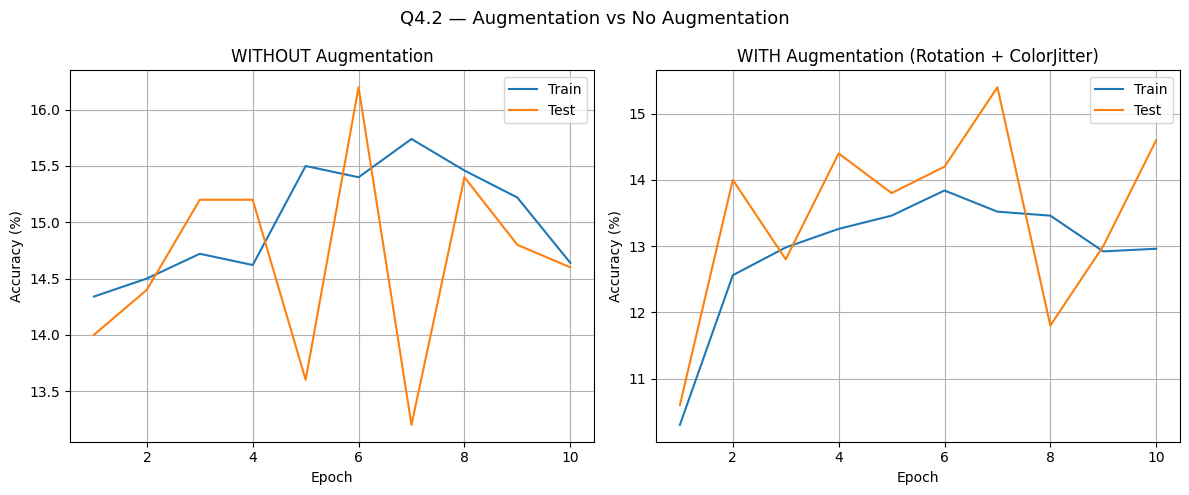

Saved: q4_2_augmentation.png

--- Q4.2 Final Test Accuracy ---
Without Augmentation : 14.60%
With    Augmentation : 14.60%


In [ ]:
epochs = range(1, len(train_a) + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_a, label='Train'); plt.plot(epochs, test_a, label='Test')
plt.title("WITHOUT Augmentation"); plt.xlabel("Epoch"); plt.ylabel("Accuracy (%)"); plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, train_b, label='Train'); plt.plot(epochs, test_b, label='Test')
plt.title("WITH Augmentation (Rotation + ColorJitter)"); plt.xlabel("Epoch"); plt.ylabel("Accuracy (%)"); plt.legend(); plt.grid(True)

plt.suptitle("Q4.2 — Augmentation vs No Augmentation", fontsize=13)
plt.tight_layout()
plt.savefig('q4_2_augmentation.png', dpi=120)
plt.show()
print("Saved: q4_2_augmentation.png")

print(f"\n--- Q4.2 Final Test Accuracy ---")
print(f"Without Augmentation : {test_a[-1]:.2f}%")
print(f"With    Augmentation : {test_b[-1]:.2f}%")